# LIBRARIES

In [1]:
import pandas as pd 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import sys
import matplotlib.pyplot as plt # type: ignore
import warnings

# Import files from ../Scripts
sys.path.append('../Scripts')
from PEMModel import ELCellStack

sys.path.append('../Data')

# Load autoreload extension
%load_ext autoreload
%autoreload 2

# DATA LOAD

### MEMBRANE THINNING DATA

In [13]:
df_membrane.head()

,Time,CHO,CH2O2,FRR_value,lm,TR,lm_check,dx_dt_numerical
0,0.000000,8.726878e-12,635783.941674,6.884518e-08,0.017800,0.209894,0.017800,-0.209894
1,0.001001,8.726878e-12,635783.941674,6.884518e-08,0.017590,0.209894,0.017590,-0.208655
2,0.002002,8.726878e-12,635783.941674,6.803256e-08,0.017382,0.207416,0.017382,-0.206192
3,0.003003,8.726878e-12,635783.941674,6.722953e-08,0.017177,0.204968,0.017177,-0.203758
4,0.004004,8.726878e-12,635783.941674,6.643598e-08,0.016974,0.202549,0.016974,-0.201353


In [17]:
k10 = 1e3 
EW = 1.100  # Nafion equivalent weight [kg/mol]
rhonaf = 1980  # Nafion dry membrane density [kg/m^3]
Cmemb = rhonaf / EW

df_membrane['v10'] = k10 * df_membrane['CHO'] * Cmemb
df_membrane['vF'] = 3.6 * df_membrane['v10']
df_membrane['FRR_check'] = df_membrane['vF'] * 18.998403 * (df_membrane['lm'] * 10 ** (-2)) * 3600 / (10 ** 4)
df_membrane

,Time,CHO,CH2O2,FRR_value,lm,TR,lm_check,dx_dt_numerical,v10,vF,FRR_check
0,0.000000,8.726878e-12,635783.941674,6.884518e-08,1.780000e-02,0.209894,1.780000e-02,-0.209894,0.000016,0.000057,6.884518e-08
1,0.001001,8.726878e-12,635783.941674,6.884518e-08,1.758990e-02,0.209894,1.758990e-02,-0.208655,0.000016,0.000057,6.803256e-08
2,0.002002,8.726878e-12,635783.941674,6.803256e-08,1.738227e-02,0.207416,1.738227e-02,-0.206192,0.000016,0.000057,6.722953e-08
3,0.003003,8.726878e-12,635783.941674,6.722953e-08,1.717710e-02,0.204968,1.717710e-02,-0.203758,0.000016,0.000057,6.643598e-08
4,0.004004,8.726878e-12,635783.941674,6.643598e-08,1.697435e-02,0.202549,1.697435e-02,-0.201353,0.000016,0.000057,6.565180e-08
...,...,...,...,...,...,...,...,...,...,...,...
995,0.995996,8.726878e-12,635783.941674,5.153293e-13,1.316663e-07,0.000002,1.316663e-07,-0.000002,0.000016,0.000057,5.092466e-13
996,0.996997,8.726878e-12,635783.941674,5.092466e-13,1.301121e-07,0.000002,1.301121e-07,-0.000002,0.000016,0.000057,5.032356e-13
997,0.997998,8.726878e-12,635783.941674,5.032356e-13,1.285764e-07,0.000002,1.285764e-07,-0.000002,0.000016,0.000057,4.972956e-13
998,0.998999,8.726878e-12,635783.941674,4.972956e-13,1.270587e-07,0.000002,1.270587e-07,-0.000002,0.000016,0.000057,4.914258e-13


In [2]:
df_membrane = pd.read_csv('../Data/membrane_thinning_data.csv')
final_time = 5e6
df_membrane['TR'] = final_time * df_membrane['FRR_value']/(0.82*2)
df_membrane['Time'] = df_membrane['Time']


df_membrane['lm_check'] = df_membrane['lm'].copy()

dt = df_membrane['Time'].values[1] - df_membrane['Time'].values[0]

for i in range(len(df_membrane) - 1):
    df_membrane.at[i + 1, 'lm_check'] = df_membrane.at[i, 'lm_check'] - df_membrane.at[i+1, 'TR'] * dt
# df_membrane['lm_check'] = df_membrane['lm_check'].iloc[:-1] - df_membrane['TR'] * dt

diff = np.abs(df_membrane['lm_check'] - df_membrane['lm'].values)
assert np.max(diff) < 1e-7, f"Max difference between lm and lm_check: {np.max(diff)}"
print('Maximum difference between lm and lm_check: ', np.max(np.abs(diff)))

df_membrane

Maximum difference between lm and lm_check:  1.1684988913962524e-16


,Time,CHO,CH2O2,FRR_value,lm,TR,lm_check
0,0.000000,8.726878e-12,635783.941674,6.884518e-08,1.780000e-02,0.209894,1.780000e-02
1,0.001001,8.726878e-12,635783.941674,6.884518e-08,1.758990e-02,0.209894,1.758990e-02
2,0.002002,8.726878e-12,635783.941674,6.803256e-08,1.738227e-02,0.207416,1.738227e-02
3,0.003003,8.726878e-12,635783.941674,6.722953e-08,1.717710e-02,0.204968,1.717710e-02
4,0.004004,8.726878e-12,635783.941674,6.643598e-08,1.697435e-02,0.202549,1.697435e-02
...,...,...,...,...,...,...,...
995,0.995996,8.726878e-12,635783.941674,5.153293e-13,1.316663e-07,0.000002,1.316663e-07
996,0.996997,8.726878e-12,635783.941674,5.092466e-13,1.301121e-07,0.000002,1.301121e-07
997,0.997998,8.726878e-12,635783.941674,5.032356e-13,1.285764e-07,0.000002,1.285764e-07
998,0.998999,8.726878e-12,635783.941674,4.972956e-13,1.270587e-07,0.000002,1.270587e-07


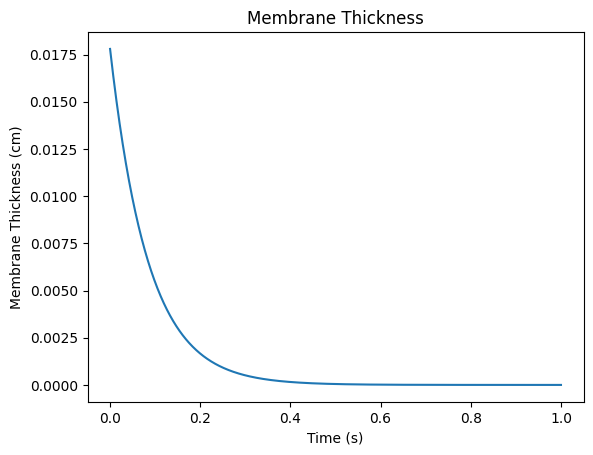

In [3]:
## Plot lm vs Time
plt.figure()
plt.plot(df_membrane['Time'], df_membrane['lm'])
plt.xlabel('Time (s)')
plt.ylabel('Membrane Thickness (cm)')
plt.title('Membrane Thickness')
plt.show()

In [4]:
################# EXAMPLE: From Difference Equation to ODE #################
# Difference equation: x[i+1] = x[i] - k * dt
# ODE: dx/dt = -k 


# Time array
t = df_membrane['Time'].values
dt = t[1] - t[0]


x = df_membrane['lm_check'].values
k = df_membrane['TR'].values 

# Numerical derivative of x
dx_dt_numerical = np.gradient(x, dt)

df_membrane['dx_dt_numerical'] = dx_dt_numerical

# Analytical derivative from the ODE: dx/dt = -k * t
dx_dt_analytical = - k


# Compute the difference between numerical and analytical derivatives
difference = dx_dt_numerical - dx_dt_analytical


print(np.max(np.abs(difference)))

# Print maximum relative error
non_zero_indices = np.where(dx_dt_analytical != 0)
max_rel_error = np.max(np.abs(difference[non_zero_indices] / dx_dt_analytical[non_zero_indices]))
max_rel_error_index = np.argmax(np.abs(difference[non_zero_indices] / dx_dt_analytical[non_zero_indices]))
print(f"Max relative error: {max_rel_error} at index {max_rel_error_index}")
print(np.abs(difference[non_zero_indices] / dx_dt_analytical[non_zero_indices]))
df_membrane

0.0012387505897538675
Max relative error: 0.005901796004344752 at index 240
[3.17367024e-15 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.90179600e-03 5.90179600e-03 5.90179600e-03 5.90179600e-03
 5.901796

,Time,CHO,CH2O2,FRR_value,lm,TR,lm_check,dx_dt_numerical
0,0.000000,8.726878e-12,635783.941674,6.884518e-08,1.780000e-02,0.209894,1.780000e-02,-0.209894
1,0.001001,8.726878e-12,635783.941674,6.884518e-08,1.758990e-02,0.209894,1.758990e-02,-0.208655
2,0.002002,8.726878e-12,635783.941674,6.803256e-08,1.738227e-02,0.207416,1.738227e-02,-0.206192
3,0.003003,8.726878e-12,635783.941674,6.722953e-08,1.717710e-02,0.204968,1.717710e-02,-0.203758
4,0.004004,8.726878e-12,635783.941674,6.643598e-08,1.697435e-02,0.202549,1.697435e-02,-0.201353
...,...,...,...,...,...,...,...,...
995,0.995996,8.726878e-12,635783.941674,5.153293e-13,1.316663e-07,0.000002,1.316663e-07,-0.000002
996,0.996997,8.726878e-12,635783.941674,5.092466e-13,1.301121e-07,0.000002,1.301121e-07,-0.000002
997,0.997998,8.726878e-12,635783.941674,5.032356e-13,1.285764e-07,0.000002,1.285764e-07,-0.000002
998,0.998999,8.726878e-12,635783.941674,4.972956e-13,1.270587e-07,0.000002,1.270587e-07,-0.000002


### VOLTAGE DATA

-------------------------- Using exponential decrease --------------------------
Standard Deviation of k1:  2.221557105636704e-16
Standard Deviation of k2:  4.16541957306882e-17
Standard Deviation of k3:  2.1694893609733436e-19
Standard Deviation of P:  4.443114211273408e-16


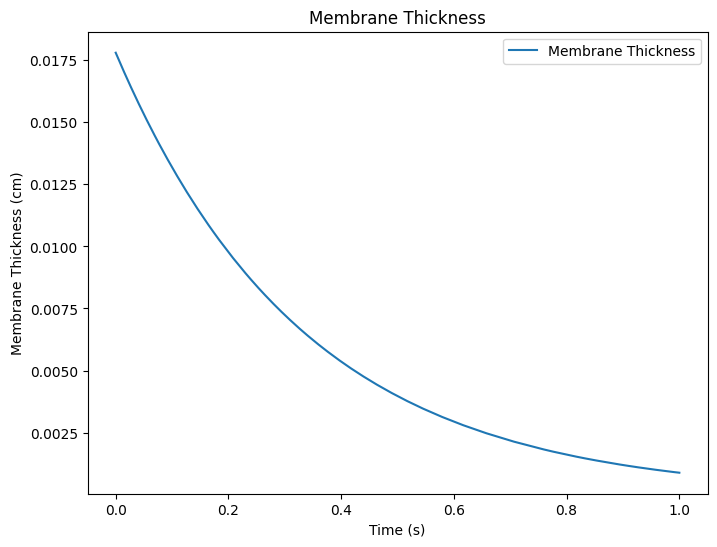

In [16]:
decrease_type = 'exponential'

print('-------------------------- Using {} decrease --------------------------'.format(decrease_type))

if decrease_type == 'linear':
    df = pd.read_csv('../Data/membrane_thinning_voltage_data_linear.csv')
elif decrease_type == 'exponential':
    df = pd.read_csv('../Data/membrane_thinning_voltage_data_exponential.csv')
elif decrease_type == 'quadratic':
    df = pd.read_csv('../Data/membrane_thinning_voltage_data_quadratic.csv')
else:
    raise ValueError('Invalid decrease type')


# Rename columns to [time, membrane_thickness, voltage, power]
df.columns = ['Time', 'memThickness', 'V','VCheck','I','ICheck','P','PCheck']
x_values = torch.tensor(df['Time'].values, dtype=torch.float32)
f_values = torch.tensor(df['VCheck'].values, dtype=torch.float32)
g_values = torch.tensor(df['memThickness'].values, dtype=torch.float32)
i_cell = torch.tensor(df['I'].values, dtype=torch.float32)

# Read constants from file
constants_df = pd.read_csv('../Data/constants.csv')
Area_cell = 680

# Constants 
k1 = torch.tensor(constants_df['k1'], dtype=torch.float32)
k2 = torch.tensor(constants_df['k2'], dtype=torch.float32)
k3 = torch.tensor(constants_df['k3'], dtype=torch.float32)
lm = torch.tensor(df['memThickness'].values, dtype=torch.float32)
P = torch.tensor((df['P']/Area_cell), dtype=torch.float32)

# Constants Mean
k1_mean_torch = torch.tensor(constants_df['k1'].mean(), dtype=torch.float32)
k2_mean_torch = torch.tensor(constants_df['k2'].mean(), dtype=torch.float32)
k3_mean_torch = torch.tensor(constants_df['k3'].mean(), dtype=torch.float32)
P_mean_torch = torch.tensor((df['P']/Area_cell).mean(), dtype=torch.float32)

# Print standard deviation of constansts
print('Standard Deviation of k1: ', constants_df['k1'].std())
print('Standard Deviation of k2: ', constants_df['k2'].std())
print('Standard Deviation of k3: ', constants_df['k3'].std())
print('Standard Deviation of P: ', (df['P']/Area_cell).std())

k1_mean = constants_df['k1'].mean()
k2_mean = constants_df['k2'].mean()
k3_mean = constants_df['k3'].mean()
P_mean = (df['P']/Area_cell).mean()

# Plot the membrane data
plt.figure(figsize=(8,6))
plt.plot(x_values, g_values, label='Membrane Thickness')
plt.xlabel('Time (s)')
plt.ylabel('Membrane Thickness (cm)')
plt.title('Membrane Thickness')
plt.legend()
plt.show()

In [17]:
############# FIRST TEST: Check that i_cell = P/V_cell #############

### First way of computing V_cell
V_cell = k1 + k2 * torch.log(i_cell) + k3 * (1/lm) * i_cell

### Second way of computing V_cell
V_cell2 = k1 + k2 * torch.log(P/V_cell) + k3 * (1/lm) * P/V_cell

# Check that the two ways of computing V_cell are the same
diff = torch.abs(V_cell2 - torch.tensor(df['VCheck'].values, dtype=torch.float64))
assert torch.max(diff) < 1e-3, f"Max difference between V and f_values: {torch.max(diff)} at index {torch.argmax(diff).item()}"

diff2 = V_cell2 - V_cell
assert torch.max(diff2) < 1e-3, f"Max difference between V_cell and V_cell2: {torch.max(diff2)}"

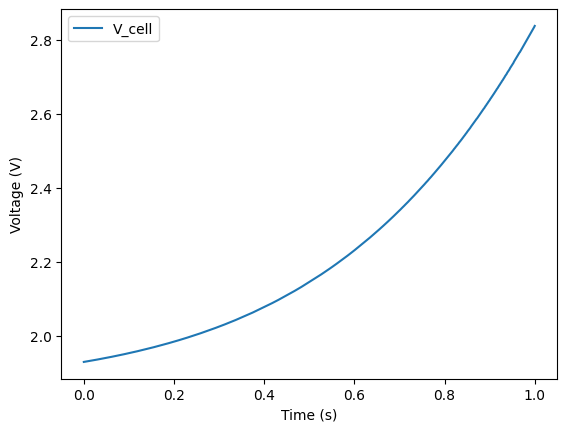

In [18]:
V_cell_constant = k1_mean_torch + k2_mean_torch * torch.log(i_cell) + k3_mean_torch * (1/lm) * i_cell
V_cell_constant_2 = k1_mean_torch + k2_mean_torch * torch.log(P/V_cell2) + k3_mean_torch * (1/lm) * (P/V_cell2)
# V_cell_constant = k1 + k2 * torch.log(i_cell) + k3* (1/lm) * i_cell
## Plot V_cell
plt.plot(df['Time'], V_cell, label='V_cell')
# Plot as dashed lines V_cell2
# plt.plot(df['Time'], V_cell_constant, label='V_cell_constant', linestyle='dashed')
# plt.plot(df['Time'], V_cell_constant_2, label='V_cell_constant', linestyle='dashed')
#Add voltage as y label and time as x label
plt.ylabel('Voltage (V)')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

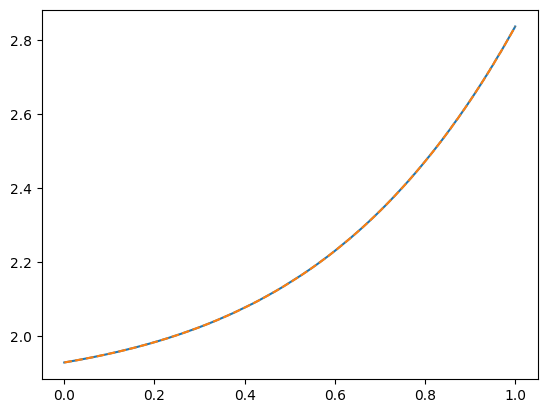

In [19]:
### First way of computing V_cell
V_cell = k1 + k2 * torch.log(i_cell) + k3 * (1/lm) * i_cell

### Second way of computing V_cell
V_cell2 = k1 + k2 * torch.log(P/V_cell) + k3 * (1/lm) * P/V_cell

## Plot V_cell
plt.plot(df['Time'], V_cell, label='V_cell')
# Plot as dashed lines V_cell2
plt.plot(df['Time'], f_values, label='V_cell2', linestyle='dashed')

### SYNTHETIC EXAMPLE 

In [14]:
# Function to generate training data
def generate_data(n_samples=1000, ini=-0.5, fin=0.5, f_func=None, g_func=None):
    x = torch.linspace(ini, fin, n_samples).reshape(-1, 1)
    if g_func:
        y2 = g_func(x)
    else:
        raise ValueError("g_func is required")
    if f_func:
        y1 = f_func(x, y2)
    else:
        raise ValueError("f_func is required")
    return x, y1, y2

# SYSTEM OF ODE

### EXAMPLE OF USE

Epoch 0, Total Loss: 0.9656336903572083, MSE Loss: 0.7918980717658997, Physics Loss: 0.1737356185913086
Epoch 100, Total Loss: 0.05202491953969002, MSE Loss: 0.00466625252738595, Physics Loss: 0.047358665615320206
Epoch 200, Total Loss: 0.033274680376052856, MSE Loss: 0.00341895897872746, Physics Loss: 0.029855722561478615
Epoch 300, Total Loss: 0.024672241881489754, MSE Loss: 0.0015630237758159637, Physics Loss: 0.02310921810567379
Epoch 400, Total Loss: 0.021850621327757835, MSE Loss: 0.0007774248952046037, Physics Loss: 0.021073196083307266
Epoch 500, Total Loss: 0.020770343020558357, MSE Loss: 0.000733806227799505, Physics Loss: 0.02003653720021248
Epoch 600, Total Loss: 0.021946731954813004, MSE Loss: 0.0031493452843278646, Physics Loss: 0.018797386437654495
Epoch 700, Total Loss: 0.019989222288131714, MSE Loss: 0.0015364924911409616, Physics Loss: 0.018452730029821396
Epoch 800, Total Loss: 0.026966173201799393, MSE Loss: 0.007394115440547466, Physics Loss: 0.019572056829929352
E

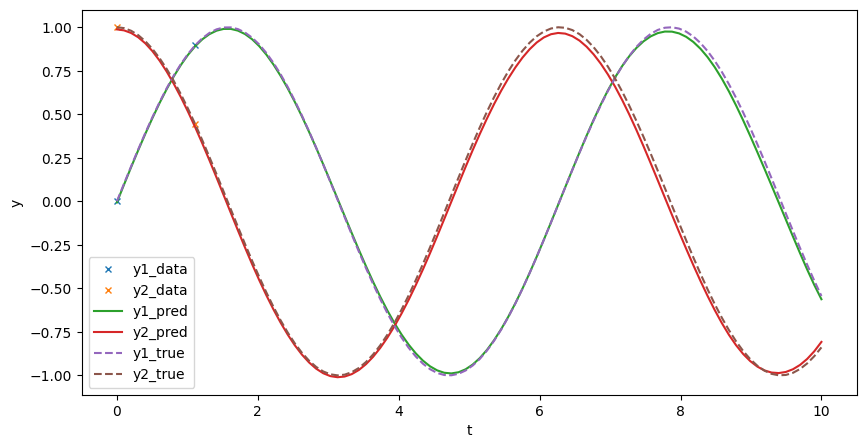

In [15]:
# Define the neural network architecture
class PINN(nn.Module):
    def __init__(self, t0, y01, y02):
        super(PINN, self).__init__()
        self.hidden = nn.Sequential(
            nn.Linear(1, 10),
            nn.Sigmoid(),
            nn.Linear(10, 10),
            nn.Sigmoid(),
            nn.Linear(10, 10),
            nn.Sigmoid()
        )
        self.output1 = nn.Linear(10, 1)  # First output
        self.output2 = nn.Linear(10, 1)  # Second output

        # Initial conditions
        self.t0 = t0
        self.y01 = y01
        self.y02 = y02

    def forward(self, x):
        features = self.hidden(x)
        # y1 = torch.exp(self.output1(features))  # f(x) prediction
        # y2 = torch.exp(self.output2(features))  # g(x) prediction
        y1 = self.output1(features)  # f(x) prediction
        y2 = self.output2(features)  # g(x) prediction
        return y1, y2

# Define the system of ODEs
def ode_system(y1, y2, dy1_dt, dy2_dt, t):
    # Example ODE system with interdependence
    # eq1 = dy1_dt - (-0.5 * y1 + 0.1 * y2 + 0.2 * dy2_dt)  # Example ODE 1
    # eq2 = dy2_dt - (0.2 * y1 - 0.3 * y2 + 0.1 * dy1_dt)   # Example ODE 2
    # cos = (0.5*sin + cos - 0.5*sin )
    # sin = (0.5*cos - sin + 0.5*cos)
    eq1 = dy1_dt - (0.5 * y1 + y2 + 0.5 *dy2_dt )  # Example ODE 1
    eq2 = dy2_dt - (0.5 * y2 - y1 - 0.5 *dy1_dt)   # Example ODE 2
    return eq1, eq2

# Define the combined loss function with weighted terms
def loss_function(model, t_data, y1_data, y2_data, t_physics, lambda_mse, lambda_physics):
    # Data-driven loss (MSE over training points)
    y1_pred_data, y2_pred_data = model(t_data)
    mse_loss = torch.mean((y1_pred_data - y1_data)**2) + torch.mean((y2_pred_data - y2_data)**2)
    # total_loss = mse_loss
    # physics_loss = torch.tensor(0.0)

    # Physics-based loss (ODE residuals over collocation points)
    t_physics.requires_grad_(True)
    y1_pred_physics, y2_pred_physics = model(t_physics)

    # Compute gradients
    dy1_dt = torch.autograd.grad(y1_pred_physics, t_physics, torch.ones_like(y1_pred_physics), create_graph=True)[0]
    dy2_dt = torch.autograd.grad(y2_pred_physics, t_physics, torch.ones_like(y2_pred_physics), create_graph=True)[0]

    # Compute the ODE residuals
    eq1, eq2 = ode_system(y1_pred_physics, y2_pred_physics, dy1_dt, dy2_dt, t_physics)
    physics_loss = torch.mean(eq1**2) + torch.mean(eq2**2)

    # Weighted total loss
    total_loss = lambda_mse * mse_loss + lambda_physics * physics_loss
    return total_loss, mse_loss, physics_loss

# Training loop
def train_pinn(model, t_data, y1_data, y2_data, t_physics, lambda_mse, lambda_physics, epochs=1000, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        optimizer.zero_grad()
        total_loss, mse_loss, physics_loss = loss_function(model, t_data, y1_data, y2_data, t_physics, lambda_mse, lambda_physics)
        total_loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Total Loss: {total_loss.item()}, MSE Loss: {mse_loss.item()}, Physics Loss: {physics_loss.item()}")

# Generate training data (observed data points)
ini = 0
fin = 10
t_data = torch.linspace(ini, fin, 10).view(-1, 1)
y1_data = torch.sin(t_data)  # Example true solution for y1
y2_data = torch.cos(t_data)  # Example true solution for y2

# Select the n first points
n = 2
t_data = t_data[:n]
y1_data = y1_data[:n]
y2_data = y2_data[:n]

# Generate collocation points (physics-based loss points)
t_physics = torch.linspace(ini, fin, 100).view(-1, 1)

# Initial conditions
t0 = torch.tensor([0.0])
y01 = torch.tensor([0.0])  # y1(t=0) = 0
y02 = torch.tensor([1.0])  # y2(t=0) = 1

# Initialize the model
model = PINN(t0, y01, y02)

# Weighting factors for the loss terms
lambda_mse = 1.0  # Weight for MSE loss
lambda_physics = 1.0  # Weight for physics loss

# Train the model
train_pinn(model, t_data, y1_data, y2_data, t_physics, lambda_mse, lambda_physics, epochs=3000, lr=0.1)

# Test the model
t_test = torch.linspace(ini, fin, 100).view(-1, 1)
y1_test = torch.sin(t_test)  # True solution for y1
y2_test = torch.cos(t_test)  # True solution for y2
y1_pred, y2_pred = model(t_test)
y1_pred = y1_pred.detach().numpy()
y2_pred = y2_pred.detach().numpy()

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(t_data.numpy(), y1_data.numpy(), 'x', label='y1_data', markersize=5)
plt.plot(t_data.numpy(), y2_data.numpy(), 'x', label='y2_data', markersize=5)
plt.plot(t_test.numpy(), y1_pred, label='y1_pred')
plt.plot(t_test.numpy(), y2_pred, label='y2_pred')
plt.plot(t_test.numpy(), y1_test.numpy(), label='y1_true', linestyle='dashed')
plt.plot(t_test.numpy(), y2_test.numpy(), label='y2_true', linestyle='dashed')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.show()

# PINN TRAINING

## Zero Shot Learning

#### MEMBRANE THINNING

In [5]:
# Neural Network Model
class ANN(nn.Module):
    def __init__(self, t0,y01):
        super(ANN, self).__init__()
        self.hidden = nn.Sequential(
            nn.Linear(1, 32),
            nn.Sigmoid(),
            nn.Linear(32, 32),
            nn.Sigmoid()
        )
        self.output1 = nn.Linear(32, 1)  # First output
        
        self.t0 = t0
        self.y01 = y01


    def forward(self, x):
        features = self.hidden(x)
        # y1 = torch.exp(self.output1(features)) * (x - self.t0) + self.y01   # f(x) prediction
        y1 = self.output1(features)  # f(x) prediction
        # y1 = torch.exp(self.output1(features))
        return y1
    
    def physics_loss(self, t_phys,x_phys, ode_residual_f_func):
        """
        Computes the physics-based loss for the given physical inputs and ODE residual functions.
        Args:
            t_phys (torch.Tensor): The physical input tensor.
            f_values (torch.Tensor): The target values for the first function.
            g_values (torch.Tensor): The target values for the second function.
            ode_residual_f_func (callable): A function that computes the ODE residual for the first function.
            ode_residual_g_func (callable): A function that computes the ODE residual for the second function.
        Returns:
            torch.Tensor: The computed physics-based loss.
        Example of ode_residual_f_func:
            ode_residual_f_func = lambda df_dx, dg_dx, t_phys: df_dx + dg_dx - t_phys
        Example of ode_residual_g_func:
            ode_residual_g_func = lambda dg_dx, t_phys: dg_dx - t_phys
        """
        t_phys.requires_grad = True
        y1 = self.forward(t_phys)
        f_pred= y1

        df_dx = torch.autograd.grad(f_pred, t_phys, torch.ones_like(f_pred), create_graph=True)[0]
        
        ode_residual_f = ode_residual_f_func(f_pred, df_dx, t_phys, x_phys)
        
        return torch.mean(ode_residual_f**2)
    
    def mse_loss(self, t_data, f_data):
        f_pred = self.forward(t_data)
        loss_f = nn.MSELoss()(f_pred, f_data)
        return loss_f

# Training function
def train(model, t_mse, t_phys,x_phys, y1_train, ode_residual_f_func, epochs=1000, lr=0.01,
          lambda_mse = 1.0, lambda_phys = 1.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        # y1_pred, y2_pred = model(x_train)
        # loss1 = criterion(y1_pred, y1_train)
        # loss2 = criterion(y2_pred, y2_train)
        # loss = loss1 + loss2  # Combined loss
        loss_mse = model.mse_loss(t_mse, y1_train)
        physics_loss = model.physics_loss(t_phys,x_phys, ode_residual_f_func)
        loss = lambda_phys * physics_loss + lambda_mse * loss_mse
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Total Loss = {loss.item():.6f}, MSE Loss = {loss_mse.item():.6f}, Physics Loss = {physics_loss.item():.6f}")
    print("Training complete!")

# Function to plot results
def plot_results(model, t_test, t_train_mse,f_train, f_test, f_func=None):
    model.eval()
    with torch.no_grad():
        y1_pred = model(t_test)
    
    t_test_np = t_test.detach().numpy()
    t_train_mse_np = t_train_mse.detach().numpy()
    y1_pred_np = y1_pred.detach().numpy()
    
    plt.figure(figsize=(12, 6))

    # Subplot for f(x)
    if f_func:
        plt.scatter(t_test_np, f_func(t_test_np), label="True f(x)", alpha=0.5)
        plt.scatter(t_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, f_func(t_train_mse_np), label="Training f(x)", marker='o', s=30, edgecolor='k')
    else:
        plt.scatter(t_test_np, f_test, label="True f(x)", alpha=0.5)
        plt.scatter(t_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, f_train, label="Training f(x)", marker='o', s=30, edgecolor='k')
    plt.legend()
    plt.title("True vs Predicted f(x)")
    plt.tight_layout()
    plt.show()

In [12]:
df_membrane.head()

,Time,CHO,CH2O2,FRR_value,lm,TR,lm_check,dx_dt_numerical
0,0.000000,8.726878e-12,635783.941674,6.884518e-08,0.017800,0.209894,0.017800,-0.209894
1,0.001001,8.726878e-12,635783.941674,6.884518e-08,0.017590,0.209894,0.017590,-0.208655
2,0.002002,8.726878e-12,635783.941674,6.803256e-08,0.017382,0.207416,0.017382,-0.206192
3,0.003003,8.726878e-12,635783.941674,6.722953e-08,0.017177,0.204968,0.017177,-0.203758
4,0.004004,8.726878e-12,635783.941674,6.643598e-08,0.016974,0.202549,0.016974,-0.201353


Epoch 0: Total Loss = 21.328840, MSE Loss = 2.183367, Physics Loss = 19.145473
Epoch 100: Total Loss = 0.010939, MSE Loss = 0.000013, Physics Loss = 0.010926
Epoch 200: Total Loss = 0.020525, MSE Loss = 0.003224, Physics Loss = 0.017301
Epoch 300: Total Loss = 0.003451, MSE Loss = 0.000436, Physics Loss = 0.003014
Epoch 400: Total Loss = 0.000142, MSE Loss = 0.000001, Physics Loss = 0.000141
Epoch 500: Total Loss = 0.003278, MSE Loss = 0.000281, Physics Loss = 0.002997
Epoch 600: Total Loss = 0.202673, MSE Loss = 0.022758, Physics Loss = 0.179915
Epoch 700: Total Loss = 0.000741, MSE Loss = 0.000002, Physics Loss = 0.000739
Epoch 800: Total Loss = 0.086259, MSE Loss = 0.013080, Physics Loss = 0.073179
Epoch 900: Total Loss = 0.000610, MSE Loss = 0.000042, Physics Loss = 0.000568
Training complete!


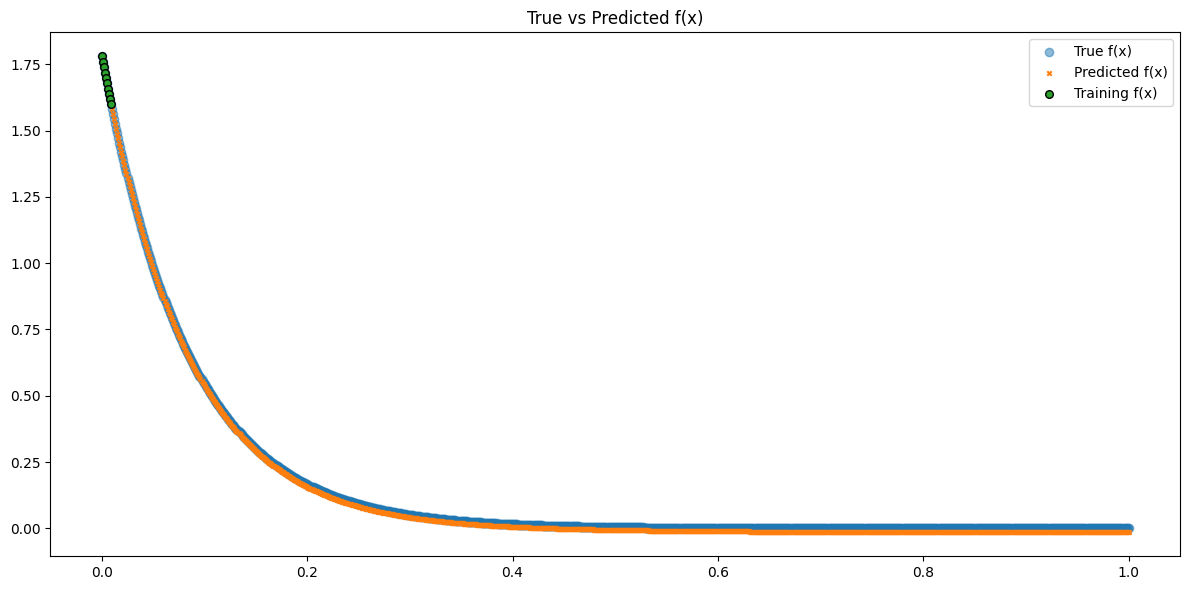

In [ ]:
# Define the functions using lambda
######################################## EXAMPLE OF USE ##################################################
# ini = 0.5
# fin = 1.5
factor = 1e2
# f_func = lambda x: x**2
# f_func = lambda x: torch.exp(x)
# ode_residual_f_func = lambda f_values, df_dx, t_phys, x_phys: df_dx  - (f_values)
t_phys = torch.tensor(df_membrane['Time'].values, dtype=torch.float32).reshape(-1, 1)
# dt = t_phys[1] - t_phys[0]
dt = torch.tensor(df_membrane['Time'].values[1] - df_membrane['Time'].values[0], dtype=torch.float32)
# k = torch.tensor(df_membrane['TR'].values, dtype=torch.float32).reshape(-1, 1)
k = torch.tensor(df_membrane['TR'].values, dtype=torch.float32).reshape(-1, 1)
df_dx_mod = factor*torch.tensor(np.gradient(df_membrane['lm_check'].values, dt), dtype=torch.float32).reshape(-1,1)

ode_residual_f_func = lambda f_values, df_dx, t_phys, x_phys: df_dx  - (-(k*factor))
###########################################################################################################

# x_train_mse, y1_train, y2_train = generate_data(ini=ini, fin=fin,f_func=f_func, g_func=g_func, n_samples=10)
# x_train_mse = torch.linspace(ini, fin, 10).reshape(-1, 1)
# y1_train = f_func(x_train_mse)
x_train_mse = torch.tensor(df_membrane['Time'].values, dtype=torch.float32).reshape(-1, 1)
y1_train = factor * torch.tensor(df_membrane['lm_check'].values, dtype=torch.float32).reshape(-1, 1)

# Select only the first n points
n = 10
x_train_mse, y1_train = x_train_mse[:n], y1_train[:n]

# x_phys = torch.linspace(ini, fin, 1000).reshape(-1, 1)
# x_phys, _, _ = generate_data(ini=ini, fin=fin,f_func=f_func, g_func=g_func, n_samples=1000)


t_phys = torch.tensor(df_membrane['Time'].values, dtype=torch.float32).reshape(-1, 1)

model = ANN(t0=x_train_mse[0],y01=y1_train[0])
train(
    model=model,t_mse=x_train_mse,t_phys=t_phys,
    x_phys=t_phys, y1_train= y1_train,lambda_phys=1.0, 
    lambda_mse=1.0, epochs=1000, lr = 0.1,
    ode_residual_f_func=ode_residual_f_func
    )
f_test = factor * torch.tensor(df_membrane['lm_check'].values, dtype=torch.float32).reshape(-1, 1).detach().numpy()

plot_results(model,t_phys, x_train_mse, y1_train,
                f_test=f_test, f_func=None)


In [39]:
x = df_membrane['lm_check'].values
dt = t[1] - t[0]


In [41]:
np.gradient(df_membrane['lm_check'].values, dt)

array([ 0.        , -0.00105492, -0.00316224, -0.00526072, -0.00734284,
       -0.00940115, -0.01142834, -0.01341724, -0.01536094, -0.01725274,
       -0.01908625, -0.02085542, -0.02255455, -0.02417834, -0.02572189,
       -0.02718077, -0.02855101, -0.02982913, -0.03101213, -0.03209752,
       -0.03308335, -0.03396815, -0.03475098, -0.03543142, -0.03600953,
       -0.03648587, -0.03686147, -0.03713781, -0.03731682, -0.03740083,
       -0.03739253, -0.03729501, -0.03711165, -0.03684615, -0.03650246,
       -0.03608475, -0.03559742, -0.03504499, -0.03443215, -0.03376365,
       -0.03304434, -0.03227907, -0.03147271, -0.0306301 , -0.02975602,
       -0.02885517, -0.02793216, -0.02699144, -0.02603734, -0.02507401,
       -0.02410543, -0.02313538, -0.02216741, -0.02120489, -0.02025094,
       -0.01930845, -0.0183801 , -0.01746831, -0.01657527, -0.01570294,
       -0.01485306, -0.01402714, -0.01322645, -0.01245209, -0.01170491,
       -0.01098561, -0.01029469, -0.00963246, -0.00899909, -0.00

In [38]:
np.gradient(df_membrane['lm'].values, dt)

ValueError: when 1d, distances must match the length of the corresponding dimension

Epoch 0: Total Loss = 0.587045, MSE Loss = 0.587045, Physics Loss = 0.483472
Epoch 100: Total Loss = 0.013246, MSE Loss = 0.013246, Physics Loss = 0.489379
Epoch 200: Total Loss = 0.003392, MSE Loss = 0.003392, Physics Loss = 0.456857
Epoch 300: Total Loss = 0.000000, MSE Loss = 0.000000, Physics Loss = 0.450665
Epoch 400: Total Loss = 0.000000, MSE Loss = 0.000000, Physics Loss = 0.450529
Epoch 500: Total Loss = 0.000000, MSE Loss = 0.000000, Physics Loss = 0.450529
Epoch 600: Total Loss = 0.000000, MSE Loss = 0.000000, Physics Loss = 0.450529
Epoch 700: Total Loss = 0.000000, MSE Loss = 0.000000, Physics Loss = 0.450529
Epoch 800: Total Loss = 0.000000, MSE Loss = 0.000000, Physics Loss = 0.450529
Epoch 900: Total Loss = 0.000000, MSE Loss = 0.000000, Physics Loss = 0.450529
Epoch 1000: Total Loss = 0.000000, MSE Loss = 0.000000, Physics Loss = 0.450529
Epoch 1100: Total Loss = 0.000000, MSE Loss = 0.000000, Physics Loss = 0.450529
Epoch 1200: Total Loss = 0.000000, MSE Loss = 0.0000

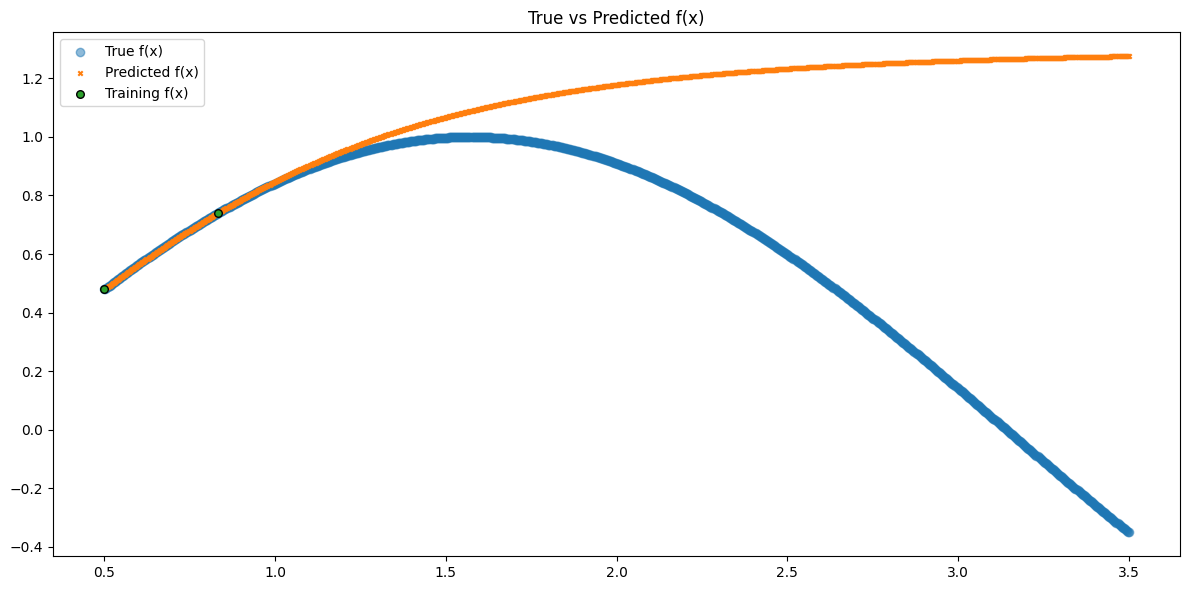

In [ ]:
# Define the functions using lambda
######################################## EXAMPLE OF USE ##################################################
ini = 0.5
fin = 3.5
# f_func = lambda x: x**2
f_func = lambda x: torch.sin(x)
ode_residual_f_func = lambda f_values, df_dx, t_phys, x_phys: df_dx  - (torch.cos(t_phys))
###########################################################################################################

# x_train_mse, y1_train, y2_train = generate_data(ini=ini, fin=fin,f_func=f_func, g_func=g_func, n_samples=10)
x_train_mse = torch.linspace(ini, fin, 10).reshape(-1, 1)
y1_train = f_func(x_train_mse)

# Select only the first n points
n = 2
x_train_mse, y1_train = x_train_mse[:n], y1_train[:n]

x_phys = torch.linspace(ini, fin, 1000).reshape(-1, 1)
# x_phys, _, _ = generate_data(ini=ini, fin=fin,f_func=f_func, g_func=g_func, n_samples=1000)


model = ANN(t0=x_train_mse[0],y01=y1_train[0])
train(model=model,t_mse=x_train_mse,t_phys=x_phys, x_phys=x_phys, y1_train= y1_train,lambda_phys=1.0, lambda_mse=1.0, epochs=2000,
        ode_residual_f_func=ode_residual_f_func)
f_test = f_func(x_phys).detach().numpy()

plot_results(model,x_phys, x_train_mse, y1_train,
                f_test=f_test, f_func=None)


Epoch 0: Total Loss = 0.545031, MSE Loss = 0.544549, Physics Loss = 0.000482
Epoch 100: Total Loss = 0.000639, MSE Loss = 0.000156, Physics Loss = 0.000482
Epoch 200: Total Loss = 0.000607, MSE Loss = 0.000125, Physics Loss = 0.000482
Epoch 300: Total Loss = 0.000585, MSE Loss = 0.000102, Physics Loss = 0.000482
Epoch 400: Total Loss = 0.000570, MSE Loss = 0.000087, Physics Loss = 0.000482
Epoch 500: Total Loss = 0.000559, MSE Loss = 0.000077, Physics Loss = 0.000482
Epoch 600: Total Loss = 0.000552, MSE Loss = 0.000070, Physics Loss = 0.000482
Epoch 700: Total Loss = 0.000547, MSE Loss = 0.000065, Physics Loss = 0.000482
Epoch 800: Total Loss = 0.000543, MSE Loss = 0.000061, Physics Loss = 0.000482
Epoch 900: Total Loss = 0.000540, MSE Loss = 0.000058, Physics Loss = 0.000482
Training complete!


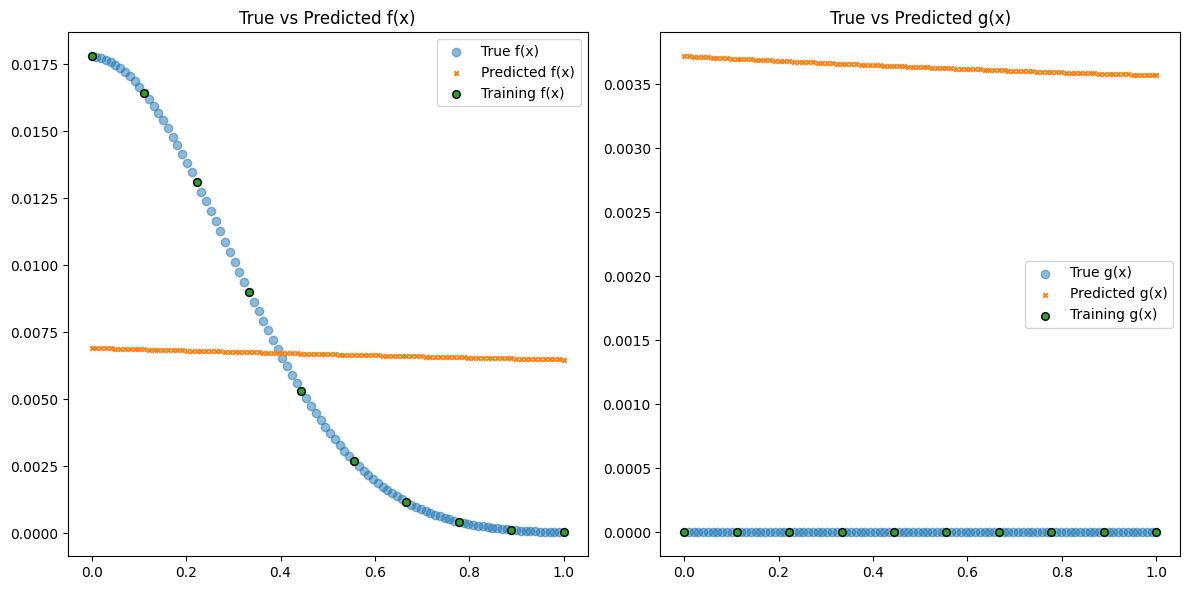

#### VOLTAGE EQUATION

In [20]:
# Neural Network Model
class DualOutputNN(nn.Module):
    def __init__(self, t0,y01, y02):
        super(DualOutputNN, self).__init__()
        self.hidden = nn.Sequential(
            nn.Linear(1, 32),
            nn.Sigmoid(),
            nn.Linear(32, 32),
            nn.Sigmoid()
        )
        self.output1 = nn.Linear(32, 1)  # First output
        self.output2 = nn.Linear(32, 1)  # Second output
        
        self.t0 = t0
        self.y01 = y01
        self.y02 = y02


    def forward(self, x):
        features = self.hidden(x)
        # y1 = torch.exp(self.output1(features)) * (x - self.t0) + self.y01   # f(x) prediction
        # y2 = torch.exp(self.output2(features)) * (x - self.t0) + self.y02   # g(x) prediction
        # y1 = self.output1(features)  # f(x) prediction
        # y2 = self.output2(features)  # g(x) prediction
        y1 = torch.exp(self.output1(features))
        y2 = torch.exp(self.output2(features))
        return y1, y2
    
    def physics_loss(self, t_phys,x_phys, ode_residual_f_func, ode_residual_g_func,lambda_phys_f, lambda_phys_g):
        """
        Computes the physics-based loss for the given physical inputs and ODE residual functions.
        Args:
            t_phys (torch.Tensor): The physical input tensor.
            f_values (torch.Tensor): The target values for the first function.
            g_values (torch.Tensor): The target values for the second function.
            ode_residual_f_func (callable): A function that computes the ODE residual for the first function.
            ode_residual_g_func (callable): A function that computes the ODE residual for the second function.
        Returns:
            torch.Tensor: The computed physics-based loss.
        Example of ode_residual_f_func:
            ode_residual_f_func = lambda df_dx, dg_dx, t_phys: df_dx + dg_dx - t_phys
        Example of ode_residual_g_func:
            ode_residual_g_func = lambda dg_dx, t_phys: dg_dx - t_phys
        """
        t_phys.requires_grad = True
        y1, y2 = self.forward(t_phys)
        f_pred, g_pred = y1, y2

        df_dx = torch.autograd.grad(f_pred, t_phys, torch.ones_like(f_pred), create_graph=True)[0]
        dg_dx = torch.autograd.grad(g_pred, t_phys, torch.ones_like(g_pred), create_graph=True)[0]
        
        ode_residual_f = ode_residual_f_func(f_pred, g_pred, df_dx, dg_dx, t_phys, x_phys)
        ode_residual_g = ode_residual_g_func(g_pred,dg_dx, t_phys)
        
        return lambda_phys_f*torch.mean(ode_residual_f**2) + lambda_phys_g*torch.mean(ode_residual_g**2)
    
    def mse_loss(self, t_data, f_data, g_data,lambda_mse_f, lambda_mse_g):
        f_pred, g_pred = self.forward(t_data)
        # f_pred, g_pred = u_pred[:, 0:1], u_pred[:, 1:2]
        loss_f = nn.MSELoss()(f_pred, f_data)
        loss_g = nn.MSELoss()(g_pred, g_data)
        return lambda_mse_f*loss_f + lambda_mse_g*loss_g

# Training function
def train(model, t_mse, t_phys,x_phys, y1_train, y2_train, ode_residual_f_func, ode_residual_g_func, epochs=1000, lr=0.001,
          lambda_mse = 1.0, lambda_phys = 1.0, lambda_phys_f = 1.0, lambda_phys_g = 1.0, lambda_mse_f = 1.0, lambda_mse_g = 1.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        # y1_pred, y2_pred = model(x_train)
        # loss1 = criterion(y1_pred, y1_train)
        # loss2 = criterion(y2_pred, y2_train)
        # loss = loss1 + loss2  # Combined loss
        loss_mse = model.mse_loss(t_mse, y1_train, y2_train,lambda_mse_f=lambda_mse_f, lambda_mse_g=lambda_mse_g)
        physics_loss = model.physics_loss(t_phys,x_phys, ode_residual_f_func, ode_residual_g_func, 
                                          lambda_phys_f=lambda_phys_f, lambda_phys_g=lambda_phys_g)
        loss = lambda_phys * physics_loss + lambda_mse * loss_mse
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Total Loss = {loss.item():.6f}, MSE Loss = {loss_mse.item():.6f}, Physics Loss = {physics_loss.item():.6f}")
    print("Training complete!")

# Function to plot results
def plot_results(model, t_test, t_train_mse,f_train,g_train, f_test, g_test, f_func=None, g_func=None,figsize=(12,6)):
    model.eval()
    with torch.no_grad():
        y1_pred, y2_pred = model(t_test)
    
    t_test_np = t_test.detach().numpy()
    t_train_mse_np = t_train_mse.detach().numpy()
    y1_pred_np = y1_pred.detach().numpy()
    y2_pred_np = y2_pred.detach().numpy()
    
    plt.figure(figsize=figsize)

    # Subplot for f(x)
    plt.subplot(1, 2, 1)
    if f_func:
        plt.scatter(t_test_np, f_func(t_test_np), label="True f(x)", alpha=0.5)
        plt.scatter(t_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, f_func(t_train_mse_np), label="Training f(x)", marker='o', s=30, edgecolor='k')
    else:
        plt.scatter(t_test_np, f_test, label="True f(x)", alpha=0.5)
        plt.scatter(t_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, f_train, label="Training f(x)", marker='o', s=30, edgecolor='k')
    plt.legend()
    plt.title("True vs Predicted f(x)")

    # Subplot for g(x)
    plt.subplot(1, 2, 2)
    if g_func:
        plt.scatter(t_test_np, g_func(t_test_np), label="True g(x)", alpha=0.5)
        plt.scatter(t_test_np, y2_pred_np, label="Predicted g(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, g_func(t_train_mse_np), label="Training g(x)", marker='o', s=30, edgecolor='k')
    else:
        plt.scatter(t_test_np, g_test, label="True g(x)", alpha=0.5)
        plt.scatter(t_test_np, y2_pred_np, label="Predicted g(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, g_train, label="Training g(x)", marker='o', s=30, edgecolor='k')
    
    plt.legend()
    plt.title("True vs Predicted g(x)")

    plt.tight_layout()
    plt.show()



------------------------------- QUADRATIC DECREASE ------------------------
Epoch 0: Total Loss = 4.733705, MSE Loss = 3.383363, Physics Loss = 1.350342
Epoch 100: Total Loss = 0.927687, MSE Loss = 0.013928, Physics Loss = 0.913758
Epoch 200: Total Loss = 0.585770, MSE Loss = 0.015777, Physics Loss = 0.569993
Epoch 300: Total Loss = 0.475133, MSE Loss = 0.012972, Physics Loss = 0.462161
Epoch 400: Total Loss = 0.352896, MSE Loss = 0.012529, Physics Loss = 0.340367
Epoch 500: Total Loss = 0.208483, MSE Loss = 0.011096, Physics Loss = 0.197388
Epoch 600: Total Loss = 0.085099, MSE Loss = 0.007064, Physics Loss = 0.078035
Epoch 700: Total Loss = 0.028380, MSE Loss = 0.002712, Physics Loss = 0.025668
Epoch 800: Total Loss = 0.014776, MSE Loss = 0.001021, Physics Loss = 0.013754
Epoch 900: Total Loss = 0.011489, MSE Loss = 0.000600, Physics Loss = 0.010889
Epoch 1000: Total Loss = 0.010005, MSE Loss = 0.000443, Physics Loss = 0.009562
Epoch 1100: Total Loss = 0.009047, MSE Loss = 0.000348, 

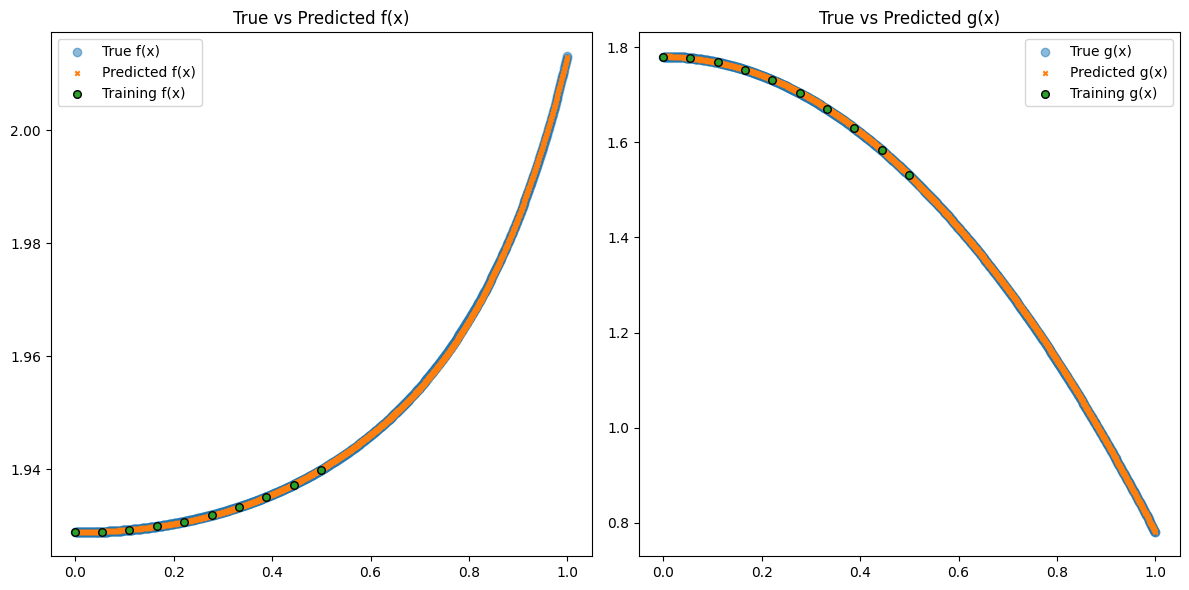

In [15]:
### VOLTAGE TRAINING
torch.manual_seed(0)

## Print at the beginning that this is the quadratic case
print('------------------------------- QUADRATIC DECREASE ------------------------')

# Check that decrease_type == 'quadratic' if not raise warning
if decrease_type != 'quadratic':
        warnings.warn("decrease_type is not quadratic")

ini = 0.5
fin = 1.5
factor = 1e2
Area_cell = 680
k4 = (1e-6*1e4)*factor
k4_mean_torch = torch.tensor(k4, dtype=torch.float64)
t_phys = torch.tensor(df['Time'].values, dtype=torch.float32).reshape(-1, 1)
P_area = torch.tensor(df['P'].values/Area_cell, dtype=torch.float32).reshape(-1, 1)
initial_thickness = torch.tensor(df['memThickness'].values[0], dtype=torch.float32)



############## OPTION 1: USING I_cell values to compute V_cell  ################
# V_cell = k1 + k2 * torch.log(i_cell) + k3 * (1/lm) * i_cell
# f_func = lambda x,y: k1_mean_torch*torch.ones_like(x) + k2_mean_torch*torch.log(x) + k3_mean_torch * (factor/y) * x
# x_phys = i_cell.reshape(-1,1)
# # Compute the numerical derivative of x_phys with respect to t_phys
# dx_dt = torch.gradient(x_phys.squeeze(), spacing=(t_phys.squeeze(),))[0].reshape(-1, 1)
####### TODO: FALTA EL TERMINO DE d_icell/dx
# ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, t_phys, x_phys: df_dx  - (k2_mean_torch/x_phys*dx_dt+ k3_mean_torch * factor * ((1/g_values)*dx_dt+x_phys*(-dg_dx/g_values**2)))

#############  OPTION 2: USING directly V_cell values  ################
# V_cell = k1 + k2*torch.log(P/V_cell) + k3*(1/lm)*P/V_cell
# f_func = lambda x,y: k1_mean_torch*torch.ones_like(x) + k2_mean_torch*torch.log(P_area/x) + k3_mean_torch * (factor/y) * P_area/x
x_phys = f_values.reshape(-1, 1)
# Compute the numerical derivative of x_phys with respect to t_phys
# dx_dt = torch.gradient(x_phys.squeeze(), spacing=(t_phys.squeeze(),))[0].reshape(-1, 1)
# ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, t_phys, x_phys: df_dx  - (-k2_mean_torch/x_phys*dx_dt+ k3_mean_torch * factor * ((1/g_values)*dx_dt+x_phys*(-dg_dx/g_values**2)))
ode_residual_f_func = lambda f_predd, g_predd, df_dx, dg_dx, t_phys, x_phys: df_dx  - (-k2_mean_torch * df_dx/f_predd + k3_mean_torch * factor * P_area*(-(dg_dx/(f_predd*g_predd**2))-((df_dx)/(g_predd*f_predd**2))))


# g_func = lambda t: initial_thickness*factor - k4_mean_torch*t**2
ode_residual_g_func = lambda g_pred,dg_dx, t_phys: dg_dx - (-2*k4_mean_torch*t_phys)


t_train_mse = torch.tensor(df['Time'].values, dtype=torch.float32).reshape(-1, 1)
# x_train_mse = i_cell.reshape(-1,1)
x_train_mse = f_values.reshape(-1,1)
# y2_train = g_func(t_train_mse)
# y1_train = f_func(x_train_mse,y2_train)
y2_train = factor*torch.tensor(df['memThickness'].values, dtype=torch.float32).reshape(-1, 1)
y1_train = torch.tensor(df['VCheck'].values, dtype=torch.float32).reshape(-1, 1)
 

# Select 10 equally spaced points in the first half of the data
n = 10
half_index = len(t_train_mse) // 2
indices = torch.linspace(0, half_index - 1, n).long()
t_train_mse, x_train_mse, y1_train, y2_train = t_train_mse[indices], x_train_mse[indices], y1_train[indices], y2_train[indices]



model = DualOutputNN(t0=t_train_mse[0],y01=y1_train[0], y02=y2_train[0])
train(model=model, t_mse=t_train_mse, t_phys=t_phys,x_phys =x_phys,  y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=5000,
        lambda_phys_f=1.0, lambda_phys_g=1.0,lambda_mse_f=1.0, lambda_mse_g=1,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)

# g_test = g_func(t_phys).detach().numpy()
g_test = factor*df['memThickness'].values
f_test = df['VCheck'].values

plot_results(model,t_phys, t_train_mse, y1_train, y2_train, 
                f_test=f_test,g_test=g_test, f_func=None, g_func=None)


------------------------------- EXPONENTIAL DECREASE ------------------------
Epoch 0: Total Loss = 5.837918, MSE Loss = 3.024999, Physics Loss = 2.812919
Epoch 100: Total Loss = 2.030854, MSE Loss = 1.758516, Physics Loss = 0.272338
Epoch 200: Total Loss = 2.011875, MSE Loss = 1.799547, Physics Loss = 0.212329
Epoch 300: Total Loss = 1.993976, MSE Loss = 1.777416, Physics Loss = 0.216561
Epoch 400: Total Loss = 1.962748, MSE Loss = 1.730037, Physics Loss = 0.232711
Epoch 500: Total Loss = 1.889576, MSE Loss = 1.626887, Physics Loss = 0.262689
Epoch 600: Total Loss = 1.647775, MSE Loss = 1.321408, Physics Loss = 0.326367
Epoch 700: Total Loss = 0.399236, MSE Loss = 0.144546, Physics Loss = 0.254690
Epoch 800: Total Loss = 0.025461, MSE Loss = 0.000247, Physics Loss = 0.025214
Epoch 900: Total Loss = 0.016442, MSE Loss = 0.000105, Physics Loss = 0.016337
Epoch 1000: Total Loss = 0.011972, MSE Loss = 0.000062, Physics Loss = 0.011910
Epoch 1100: Total Loss = 0.009130, MSE Loss = 0.000040

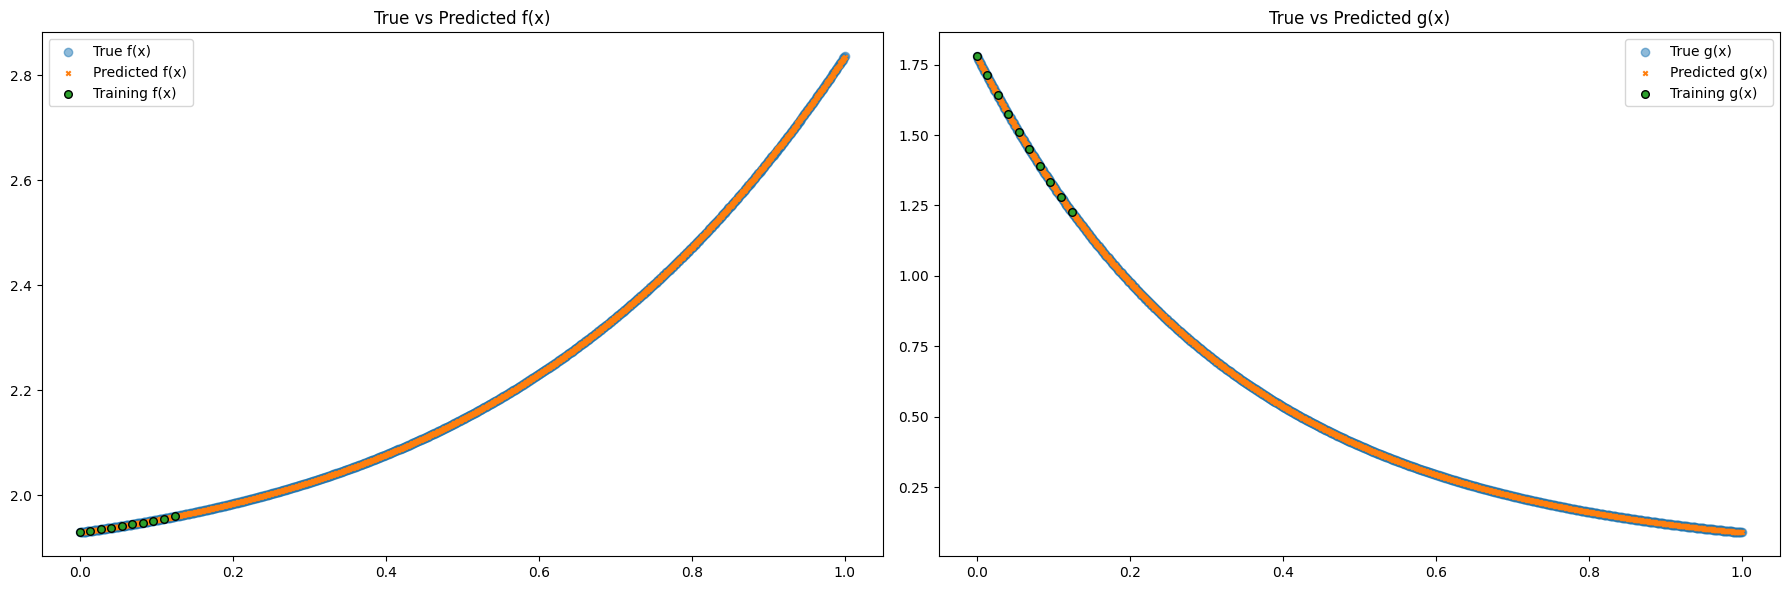

In [21]:
### VOLTAGE TRAININGa
torch.manual_seed(0)

## Print at the beginning that this is the exponential case
print('------------------------------- EXPONENTIAL DECREASE ------------------------')

# Check that decrease_type == 'exponential' if not raise warning
if decrease_type != 'exponential':
        warnings.warn("decrease_type is not exponential")

ini = 0.5
fin = 1.5
factor = 1e2
Area_cell = 680
k4 = (1e-6*1e4*3e2)
k4_mean_torch = torch.tensor(k4, dtype=torch.float64)
t_phys = torch.tensor(df['Time'].values, dtype=torch.float32).reshape(-1, 1)
P_area = torch.tensor(df['P'].values/Area_cell, dtype=torch.float32).reshape(-1, 1)
initial_thickness = torch.tensor(df['memThickness'].values[0], dtype=torch.float32)


############## OPTION 1: USING I_cell values to compute V_cell  ################
# V_cell = k1 + k2 * torch.log(i_cell) + k3 * (1/lm) * i_cell
# f_func = lambda x,y: k1_mean_torch*torch.ones_like(x) + k2_mean_torch*torch.log(x) + k3_mean_torch * (factor/y) * x
# x_phys = i_cell.reshape(-1,1)
# # Compute the numerical derivative of x_phys with respect to t_phys
# dx_dt = torch.gradient(x_phys.squeeze(), spacing=(t_phys.squeeze(),))[0].reshape(-1, 1)
####### TODO: FALTA EL TERMINO DE d_icell/dx
# ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, t_phys, x_phys: df_dx  - (k2_mean_torch/x_phys*dx_dt+ k3_mean_torch * factor * ((1/g_values)*dx_dt+x_phys*(-dg_dx/g_values**2)))

#############  OPTION 2: USING directly V_cell values  ################
# V_cell = k1 + k2*torch.log(P/V_cell) + k3*(1/lm)*P/V_cell
f_func = lambda x,y: k1_mean_torch*torch.ones_like(x) + k2_mean_torch*torch.log(P_area/x) + k3_mean_torch * (factor/y) * P_area/x
x_phys = f_values.reshape(-1, 1)
ode_residual_f_func = lambda f_predd, g_predd, df_dx, dg_dx, t_phys, x_phys: df_dx  - (-k2_mean_torch * df_dx/f_predd + k3_mean_torch * factor * P_area*(-(dg_dx/(f_predd*g_predd**2))-((df_dx)/(g_predd*f_predd**2))))


g_func = lambda t: initial_thickness * factor * torch.exp(-k4_mean_torch * t)
ode_residual_g_func = lambda g_predd, dg_dx, t_phys: dg_dx -(-k4_mean_torch * g_predd)


t_train_mse = torch.tensor(df['Time'].values, dtype=torch.float32).reshape(-1, 1)
# x_train_mse = i_cell.reshape(-1,1)
x_train_mse = f_values.reshape(-1,1)
y2_train = g_func(t_train_mse)
y1_train = f_func(x_train_mse,y2_train)
 

# Select 10 equally spaced points in the first half of the data
n = 10
half_index = len(t_train_mse) // 8
indices = torch.linspace(0, half_index - 1, n).long()
t_train_mse, x_train_mse, y1_train, y2_train = t_train_mse[indices], x_train_mse[indices], y1_train[indices], y2_train[indices]



model = DualOutputNN(t0=t_train_mse[0],y01=y1_train[0], y02=y2_train[0])
train(model=model, t_mse=t_train_mse, t_phys=t_phys,x_phys =x_phys,  y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=10000,
        lambda_phys_f=1.0, lambda_phys_g=1.0,lambda_mse_f=1.0, lambda_mse_g=1,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)

g_test = g_func(t_phys).detach().numpy()
f_test = f_func(x_phys,g_func(t_phys)).detach().numpy()

plot_results(model,t_phys, t_train_mse, y1_train, y2_train, 
                f_test=f_test,g_test=g_test, f_func=None, g_func=None,figsize=(18,6))


Epoch 0: Total Loss = 4.596940, MSE Loss = 3.580943, Physics Loss = 1.015996
Epoch 100: Total Loss = 0.015841, MSE Loss = 0.001136, Physics Loss = 0.014705
Epoch 200: Total Loss = 0.003615, MSE Loss = 0.000050, Physics Loss = 0.003565
Epoch 300: Total Loss = 0.002027, MSE Loss = 0.000023, Physics Loss = 0.002004
Epoch 400: Total Loss = 0.001049, MSE Loss = 0.000010, Physics Loss = 0.001040
Epoch 500: Total Loss = 0.000440, MSE Loss = 0.000003, Physics Loss = 0.000437
Epoch 600: Total Loss = 0.000161, MSE Loss = 0.000001, Physics Loss = 0.000160
Epoch 700: Total Loss = 0.000076, MSE Loss = 0.000000, Physics Loss = 0.000076
Epoch 800: Total Loss = 0.000053, MSE Loss = 0.000000, Physics Loss = 0.000053
Epoch 900: Total Loss = 0.000042, MSE Loss = 0.000000, Physics Loss = 0.000042
Epoch 1000: Total Loss = 0.000034, MSE Loss = 0.000000, Physics Loss = 0.000034
Epoch 1100: Total Loss = 0.000028, MSE Loss = 0.000000, Physics Loss = 0.000028
Epoch 1200: Total Loss = 0.000023, MSE Loss = 0.0000

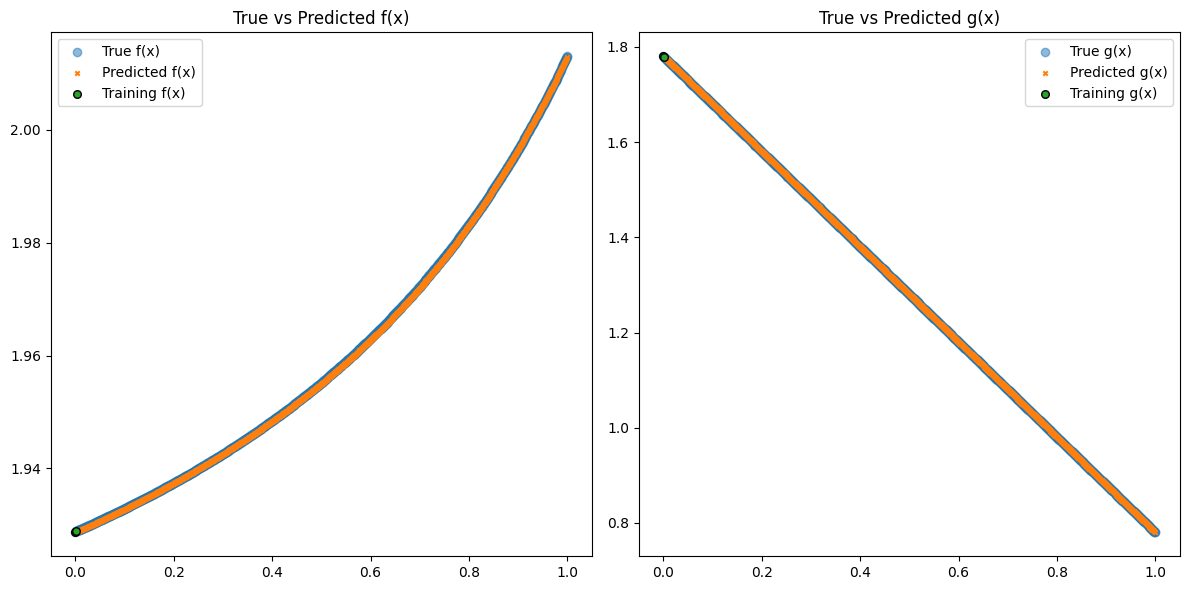

In [ ]:
### VOLTAGE TRAINING
torch.manual_seed(0)

print('------------------------------- LINEAR DECREASE ------------------------')

# Check that decrease_type == 'quadratic' if not raise warning
if decrease_type != 'linear':
        warnings.warn("decrease_type is not linear")


ini = 0.5
fin = 1.5
factor = 1e2
k4 = (1e-6*1e4)*factor
k4_mean_torch = torch.tensor(k4, dtype=torch.float64)
t_phys = torch.tensor(df['Time'].values, dtype=torch.float32).reshape(-1, 1)
x_phys = i_cell.reshape(-1,1)

# Compute the numerical derivative of x_phys with respect to t_phys
dx_dt = torch.gradient(x_phys.squeeze(), spacing=(t_phys.squeeze(),))[0].reshape(-1, 1)

# V_cell = k1 + k2 * torch.log(i_cell) + k3 * (1/lm) * i_cell
f_func = lambda x,y: k1_mean_torch*torch.ones_like(x) + k2_mean_torch*torch.log(x) + k3_mean_torch * (factor/y) * x
g_func = lambda t: 1.78e-2*factor - k4_mean_torch*t

####### TODO: FALTA EL TERMINO DE d_icell/dx
ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, t_phys, x_phys: df_dx  - (k2_mean_torch/x_phys*dx_dt+ k3_mean_torch * factor * ((1/g_values)*dx_dt+x_phys*(-dg_dx/g_values**2)))
ode_residual_g_func = lambda g_predd,dg_dx, t_phys: dg_dx - (-k4_mean_torch*torch.ones_like(t_phys))


t_train_mse = torch.tensor(df['Time'].values, dtype=torch.float32).reshape(-1, 1)
x_train_mse = i_cell.reshape(-1,1)
y2_train = g_func(t_train_mse)
y1_train = f_func(x_train_mse,y2_train)
 

# Select only the first n points
n = 2
t_train_mse, x_train_mse, y1_train, y2_train = t_train_mse[:n], x_train_mse[:n], y1_train[:n], y2_train[:n]



model = DualOutputNN(t0=t_train_mse[0],y01=y1_train[0], y02=y2_train[0])
train(model=model, t_mse=t_train_mse, t_phys=t_phys,x_phys =x_phys,  y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=3000,
        lambda_phys_f=1.0, lambda_phys_g=1.0,lambda_mse_f=1.0, lambda_mse_g=1,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)
g_test = g_func(t_phys).detach().numpy()
f_test = f_func(x_phys,g_func(t_phys)).detach().numpy()

plot_results(model,t_phys, t_train_mse, y1_train, y2_train, 
                f_test=f_test,g_test=g_test, f_func=None, g_func=None)


Epoch 0: Total Loss = 3.673325, MSE Loss = 2.438163, Physics Loss = 1.235162
Epoch 100: Total Loss = 0.000365, MSE Loss = 0.000103, Physics Loss = 0.000262
Epoch 200: Total Loss = 0.000211, MSE Loss = 0.000000, Physics Loss = 0.000211
Epoch 300: Total Loss = 0.000208, MSE Loss = 0.000000, Physics Loss = 0.000208
Epoch 400: Total Loss = 0.000204, MSE Loss = 0.000000, Physics Loss = 0.000204
Epoch 500: Total Loss = 0.000199, MSE Loss = 0.000000, Physics Loss = 0.000199
Epoch 600: Total Loss = 0.000194, MSE Loss = 0.000000, Physics Loss = 0.000194
Epoch 700: Total Loss = 0.000189, MSE Loss = 0.000000, Physics Loss = 0.000189
Epoch 800: Total Loss = 0.000183, MSE Loss = 0.000000, Physics Loss = 0.000183
Epoch 900: Total Loss = 0.000177, MSE Loss = 0.000000, Physics Loss = 0.000177
Training complete!


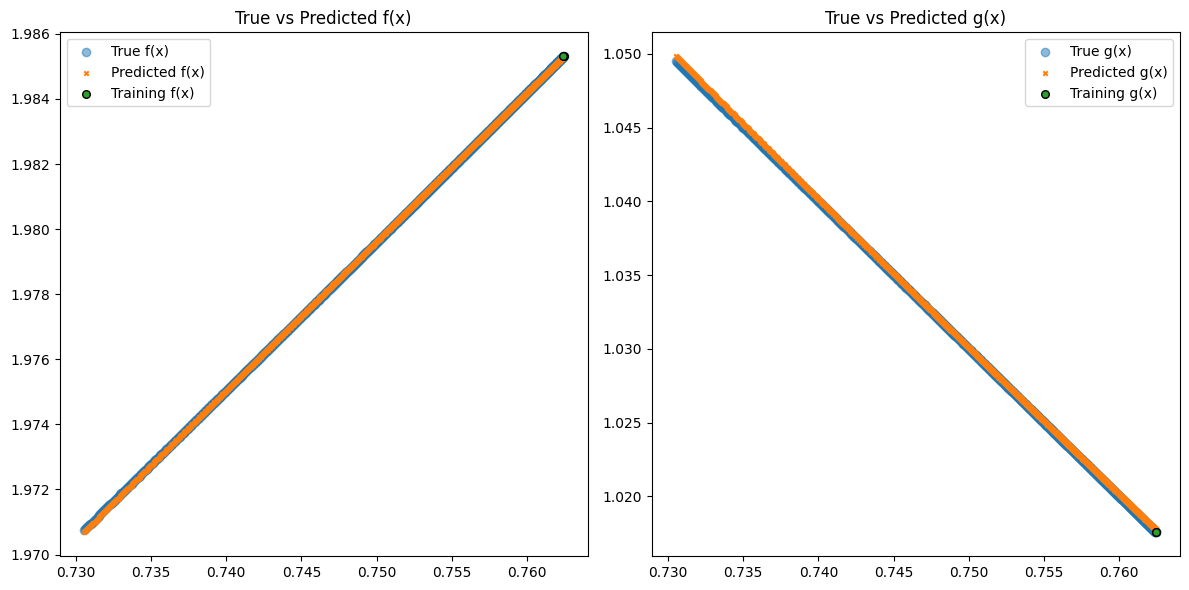

In [15]:
### VOLTAGE TRAINING
torch.manual_seed(0)
####### TODO: MODIFICAR YA QUE LA X DE G_FUN ES EL TIEMPO Y LA X DE F_FUN ES LA INTENSIDAD DE CORRIENTE
ini = 0.5
fin = 1.5
factor = 1e2
k4 = (1e-6*1e4)*factor
k4_mean_torch = torch.tensor(k4, dtype=torch.float64)
# V_cell = k1 + k2 * torch.log(i_cell) + k3 * (1/lm) * i_cell
f_func = lambda x,y: k1_mean_torch*torch.ones_like(x) + k2_mean_torch*torch.log(x) + k3_mean_torch * (factor/y) * x
g_func = lambda x: 1.78e-2*factor - k4_mean_torch*x

ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, t_phys: df_dx  - (k2_mean_torch/t_phys+ k3_mean_torch * factor * ((1/g_values)+t_phys*(-dg_dx/g_values**2)))
ode_residual_g_func = lambda dg_dx, t_phys: dg_dx - (-k4_mean_torch*torch.ones_like(t_phys))


t_train_mse = i_cell.reshape(-1,1)
y2_train = g_func(t_train_mse)
y1_train = f_func(t_train_mse,y2_train)
 

# Select only the first n points
n = 2
t_train_mse, y1_train, y2_train = t_train_mse[:n], y1_train[:n], y2_train[:n]

t_phys = i_cell.reshape(-1,1)


model = DualOutputNN(t0=t_train_mse[0],y01=y1_train[0], y02=y2_train[0])
train(model=model, t_mse=t_train_mse, t_phys=t_phys, y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=1000,
        lambda_phys_f=1.0, lambda_phys_g=1.0,lambda_mse_f=1.0, lambda_mse_g=1,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)
g_test = g_func(t_phys).detach().numpy()
f_test = f_func(t_phys,g_func(t_phys)).detach().numpy()

plot_results(model,t_phys, t_train_mse, y1_train, y2_train, 
                f_test=f_test,g_test=g_test, f_func=None, g_func=None)


In [ ]:
################## PRELIMINAR VERSION ###################

### VOLTAGE TRAINING
####### TODO: MODIFICAR YA QUE LA X DE G_FUN ES EL TIEMPO Y LA X DE F_FUN ES LA INTENSIDAD DE CORRIENTE
ini = 0.5
fin = 1.5
factor = 1e2
k4 = (1e-6*1e4)*factor
k4_mean_torch = torch.tensor(k4, dtype=torch.float64)
# V_cell = k1 + k2 * torch.log(i_cell) + k3 * (1/lm) * i_cell
f_func = lambda x,i_cell,g: k1_mean_torch*torch.ones_like(i_cell) + k2_mean_torch*torch.log(i_cell) + k3_mean_torch * (factor/g) * i_cell
g_func = lambda x: 1.78e-2*factor - k4_mean_torch*x

ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, x_phys: df_dx  - (k2_mean_torch/x_phys+ k3_mean_torch * factor * ((1/g_values)+x_phys*(-dg_dx/g_values**2)))
ode_residual_g_func = lambda dg_dx, x_phys: dg_dx - (-k4_mean_torch*torch.ones_like(x_phys))


x_train_mse = i_cell.reshape(-1,1)
y2_train = g_func(x_train_mse)
y1_train = f_func(x_train_mse,y2_train)
 

# Select only the first n points
n = 2
x_train_mse, y1_train, y2_train = x_train_mse[:n], y1_train[:n], y2_train[:n]

x_phys = i_cell.reshape(-1,1)


model = DualOutputNN(x0=x_train_mse[0],y01=y1_train[0], y02=y2_train[0])
train(model=model, x_mse=x_train_mse, x_phys=x_phys, y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=1000,
        lambda_phys_f=1.0, lambda_phys_g=1.0,lambda_mse_f=1.0, lambda_mse_g=1,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)
g_test = g_func(x_phys).detach().numpy()
f_test = f_func(x_phys,g_func(x_phys)).detach().numpy()

plot_results(model,x_phys, x_train_mse, y1_train, y2_train, 
                f_test=f_test,g_test=g_test, f_func=None, g_func=None)


TypeError: <lambda>() missing 1 required positional argument: 'g'

#### EXAMPLE OF USE

In [ ]:
# Neural Network Model
class DualOutputNN(nn.Module):
    def __init__(self, x0,y01, y02):
        super(DualOutputNN, self).__init__()
        self.hidden = nn.Sequential(
            nn.Linear(1, 32),
            nn.Sigmoid(),
            nn.Linear(32, 32),
            nn.Sigmoid()
        )
        self.output1 = nn.Linear(32, 1)  # First output
        self.output2 = nn.Linear(32, 1)  # Second output
        
        self.x0 = x0
        self.y01 = y01
        self.y02 = y02


    def forward(self, x):
        features = self.hidden(x)
        # y1 = torch.exp(self.output1(features)) * (x - self.x0) + self.y01   # f(x) prediction
        # y2 = torch.exp(self.output2(features)) * (x - self.x0) + self.y02   # g(x) prediction
        # y1 = self.output1(features)  # f(x) prediction
        # y2 = self.output2(features)  # g(x) prediction
        y1 = torch.exp(self.output1(features))
        y2 = torch.exp(self.output2(features))
        return y1, y2
    
    def physics_loss(self, x_phys, ode_residual_f_func, ode_residual_g_func,lambda_phys_f, lambda_phys_g):
        """
        Computes the physics-based loss for the given physical inputs and ODE residual functions.
        Args:
            x_phys (torch.Tensor): The physical input tensor.
            f_values (torch.Tensor): The target values for the first function.
            g_values (torch.Tensor): The target values for the second function.
            ode_residual_f_func (callable): A function that computes the ODE residual for the first function.
            ode_residual_g_func (callable): A function that computes the ODE residual for the second function.
        Returns:
            torch.Tensor: The computed physics-based loss.
        Example of ode_residual_f_func:
            ode_residual_f_func = lambda df_dx, dg_dx, x_phys: df_dx + dg_dx - x_phys
        Example of ode_residual_g_func:
            ode_residual_g_func = lambda dg_dx, x_phys: dg_dx - x_phys
        """
        x_phys.requires_grad = True
        y1, y2 = self.forward(x_phys)
        f_pred, g_pred = y1, y2

        df_dx = torch.autograd.grad(f_pred, x_phys, torch.ones_like(f_pred), create_graph=True)[0]
        dg_dx = torch.autograd.grad(g_pred, x_phys, torch.ones_like(g_pred), create_graph=True)[0]
        
        ode_residual_f = ode_residual_f_func(f_pred, g_pred, df_dx, dg_dx, x_phys)
        ode_residual_g = ode_residual_g_func(dg_dx, x_phys)
        
        return lambda_phys_f*torch.mean(ode_residual_f**2) + lambda_phys_g*torch.mean(ode_residual_g**2)
    
    def mse_loss(self, x_data, f_data, g_data,lambda_mse_f, lambda_mse_g):
        f_pred, g_pred = self.forward(x_data)
        # f_pred, g_pred = u_pred[:, 0:1], u_pred[:, 1:2]
        loss_f = nn.MSELoss()(f_pred, f_data)
        loss_g = nn.MSELoss()(g_pred, g_data)
        return lambda_mse_f*loss_f + lambda_mse_g*loss_g

# Training function
def train(model, x_mse, x_phys, y1_train, y2_train, ode_residual_f_func, ode_residual_g_func, epochs=1000, lr=0.01,
          lambda_mse = 1.0, lambda_phys = 1.0, lambda_phys_f = 1.0, lambda_phys_g = 1.0, lambda_mse_f = 1.0, lambda_mse_g = 1.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss_mse = model.mse_loss(x_mse, y1_train, y2_train,lambda_mse_f=lambda_mse_f, lambda_mse_g=lambda_mse_g)
        physics_loss = model.physics_loss(x_phys, ode_residual_f_func, ode_residual_g_func, 
                                          lambda_phys_f=lambda_phys_f, lambda_phys_g=lambda_phys_g)
        loss = lambda_phys * physics_loss + lambda_mse * loss_mse
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Total Loss = {loss.item():.6f}, MSE Loss = {loss_mse.item():.6f}, Physics Loss = {physics_loss.item():.6f}")
    print("Training complete!")

# Function to plot results
def plot_results(model, x_test, x_train_mse,f_train,g_train, f_test, g_test, f_func=None, g_func=None):
    model.eval()
    with torch.no_grad():
        y1_pred, y2_pred = model(x_test)
    
    x_test_np = x_test.detach().numpy()
    x_train_mse_np = x_train_mse.detach().numpy()
    y1_pred_np = y1_pred.detach().numpy()
    y2_pred_np = y2_pred.detach().numpy()
    
    plt.figure(figsize=(12, 6))

    # Subplot for f(x)
    plt.subplot(1, 2, 1)
    if f_func:
        plt.scatter(x_test_np, f_func(x_test_np), label="True f(x)", alpha=0.5)
        plt.scatter(x_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
        plt.scatter(x_train_mse_np, f_func(x_train_mse_np), label="Training f(x)", marker='o', s=30, edgecolor='k')
    else:
        plt.scatter(x_test_np, f_test, label="True f(x)", alpha=0.5)
        plt.scatter(x_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
        plt.scatter(x_train_mse_np, f_train, label="Training f(x)", marker='o', s=30, edgecolor='k')
    plt.legend()
    plt.title("True vs Predicted f(x)")

    # Subplot for g(x)
    plt.subplot(1, 2, 2)
    if g_func:
        plt.scatter(x_test_np, g_func(x_test_np), label="True g(x)", alpha=0.5)
        plt.scatter(x_test_np, y2_pred_np, label="Predicted g(x)", marker='x', s=10)
        plt.scatter(x_train_mse_np, g_func(x_train_mse_np), label="Training g(x)", marker='o', s=30, edgecolor='k')
    else:
        plt.scatter(x_test_np, g_test, label="True g(x)", alpha=0.5)
        plt.scatter(x_test_np, y2_pred_np, label="Predicted g(x)", marker='x', s=10)
        plt.scatter(x_train_mse_np, g_train, label="Training g(x)", marker='o', s=30, edgecolor='k')
    
    plt.legend()
    plt.title("True vs Predicted g(x)")

    plt.tight_layout()
    plt.show()



Epoch 0: Total Loss = 4.878423, MSE Loss = 0.549848, Physics Loss = 4.328575
Epoch 100: Total Loss = 0.021843, MSE Loss = 0.011479, Physics Loss = 0.010365
Epoch 200: Total Loss = 0.011410, MSE Loss = 0.003586, Physics Loss = 0.007824
Epoch 300: Total Loss = 0.006805, MSE Loss = 0.001685, Physics Loss = 0.005119
Epoch 400: Total Loss = 0.004578, MSE Loss = 0.000938, Physics Loss = 0.003640
Epoch 500: Total Loss = 0.002756, MSE Loss = 0.000566, Physics Loss = 0.002190
Epoch 600: Total Loss = 0.001436, MSE Loss = 0.000335, Physics Loss = 0.001101
Epoch 700: Total Loss = 0.000539, MSE Loss = 0.000122, Physics Loss = 0.000417
Epoch 800: Total Loss = 0.000209, MSE Loss = 0.000040, Physics Loss = 0.000169
Epoch 900: Total Loss = 0.001819, MSE Loss = 0.000099, Physics Loss = 0.001719
Training complete!


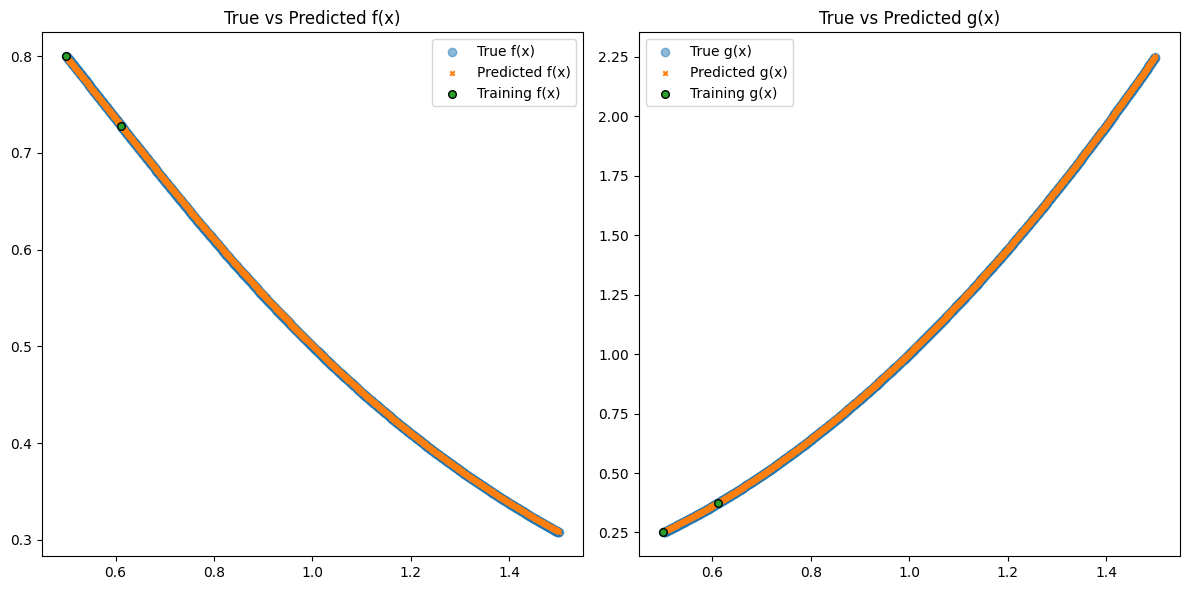

In [4]:
# Define the functions using lambda
######################################## EXAMPLE OF USE ##################################################
ini = 0.5
fin = 1.5
f_func = lambda x,y: 1/(y+1)
g_func = lambda x: x**2
ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, x_phys: df_dx  - (-dg_dx/(g_values+1)**2)
ode_residual_g_func = lambda dg_dx, x_phys: dg_dx - (2*x_phys)
# f_func = lambda x,y: x+y**2
# g_func = lambda x: torch.log(x)
# ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, x_phys: df_dx  - (torch.ones_like(x_phys) + 2*g_values*dg_dx)
# ode_residual_g_func = lambda dg_dx, x_phys: dg_dx - (1/x_phys)
###########################################################################################################

# x_train_mse, y1_train, y2_train = generate_data(ini=ini, fin=fin,f_func=f_func, g_func=g_func, n_samples=10)
x_train_mse = torch.linspace(ini, fin, 10).reshape(-1, 1)
y2_train = g_func(x_train_mse)
y1_train = f_func(x_train_mse,y2_train)

# Select only the first n points
n = 2
x_train_mse, y1_train, y2_train = x_train_mse[:n], y1_train[:n], y2_train[:n]


x_phys = torch.linspace(ini, fin, 1000).reshape(-1, 1)
# x_phys, _, _ = generate_data(ini=ini, fin=fin,f_func=f_func, g_func=g_func, n_samples=1000)


model = DualOutputNN(x0=x_train_mse[0],y01=y1_train[0], y02=y2_train[0])
train(model=model, x_mse=x_train_mse, x_phys=x_phys, y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=1000,
        lambda_phys_f=1.0, lambda_phys_g=1.0,lambda_mse_f=1.0, lambda_mse_g=1,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)
g_test = g_func(x_phys).detach().numpy()
f_test = f_func(x_phys,g_func(x_phys)).detach().numpy()

plot_results(model,x_phys, x_train_mse, y1_train, y2_train, 
                f_test=f_test,g_test=g_test, f_func=None, g_func=None)


Epoch 0: Total Loss = 5.625084, MSE Loss = 1.287667, Physics Loss = 4.337417
Epoch 100: Total Loss = 0.025839, MSE Loss = 0.008941, Physics Loss = 0.016899
Epoch 200: Total Loss = 0.013424, MSE Loss = 0.004306, Physics Loss = 0.009117
Epoch 300: Total Loss = 0.007718, MSE Loss = 0.002149, Physics Loss = 0.005569
Epoch 400: Total Loss = 0.004374, MSE Loss = 0.001190, Physics Loss = 0.003184
Epoch 500: Total Loss = 0.002084, MSE Loss = 0.000613, Physics Loss = 0.001471
Epoch 600: Total Loss = 0.000922, MSE Loss = 0.000269, Physics Loss = 0.000653
Epoch 700: Total Loss = 0.000510, MSE Loss = 0.000116, Physics Loss = 0.000395
Epoch 800: Total Loss = 0.000371, MSE Loss = 0.000060, Physics Loss = 0.000311
Epoch 900: Total Loss = 0.000303, MSE Loss = 0.000038, Physics Loss = 0.000264
Training complete!


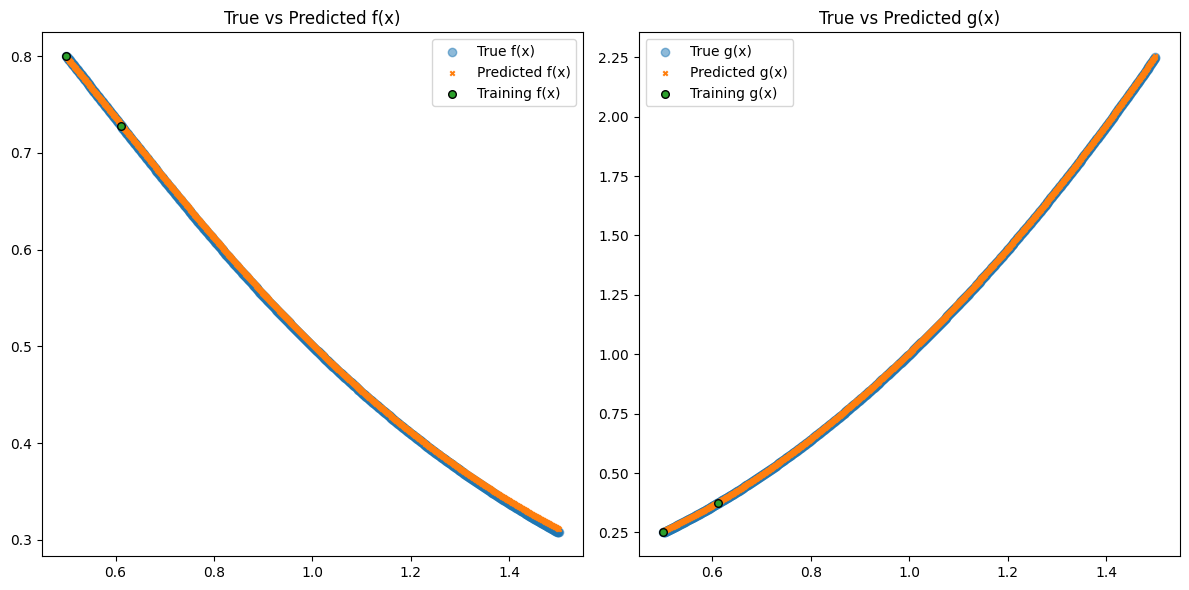

In [13]:
# Define the functions using lambda
######################################## EXAMPLE OF USE ##################################################
ini = 0.5
fin = 1.5
f_func = lambda x,y: 1/(y+1)
g_func = lambda x: x**2
ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, x_phys: df_dx  - (-dg_dx/(g_values+1)**2)
ode_residual_g_func = lambda dg_dx, x_phys: dg_dx - (2*x_phys)
# f_func = lambda x,y: x+y**2
# g_func = lambda x: torch.log(x)
# ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, x_phys: df_dx  - (torch.ones_like(x_phys) + 2*g_values*dg_dx)
# ode_residual_g_func = lambda dg_dx, x_phys: dg_dx - (1/x_phys)
###########################################################################################################

# x_train_mse, y1_train, y2_train = generate_data(ini=ini, fin=fin,f_func=f_func, g_func=g_func, n_samples=10)
x_train_mse = torch.linspace(ini, fin, 10).reshape(-1, 1)
y2_train = g_func(x_train_mse)
y1_train = f_func(x_train_mse,y2_train)

# Select only the first n points
n = 2
x_train_mse, y1_train, y2_train = x_train_mse[:n], y1_train[:n], y2_train[:n]


x_phys = torch.linspace(ini, fin, 1000).reshape(-1, 1)
# x_phys, _, _ = generate_data(ini=ini, fin=fin,f_func=f_func, g_func=g_func, n_samples=1000)


model = DualOutputNN(x0=x_train_mse[0],y01=y1_train[0], y02=y2_train[0])
train(model=model, x_mse=x_train_mse, x_phys=x_phys, y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=1000,
        lambda_phys_f=1.0, lambda_phys_g=1.0,lambda_mse_f=1.0, lambda_mse_g=1,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)
g_test = g_func(x_phys).detach().numpy()
f_test = f_func(x_phys,g_func(x_phys)).detach().numpy()

plot_results(model,x_phys, x_train_mse, y1_train, y2_train, 
                f_test=f_test,g_test=g_test, f_func=None, g_func=None)


Epoch 0: Total Loss = 3.243114, MSE Loss = 2.177156, Physics Loss = 1.065959
Epoch 100: Total Loss = 0.000132, MSE Loss = 0.000049, Physics Loss = 0.000083
Epoch 200: Total Loss = 0.000054, MSE Loss = 0.000000, Physics Loss = 0.000054
Epoch 300: Total Loss = 0.000054, MSE Loss = 0.000000, Physics Loss = 0.000054
Epoch 400: Total Loss = 0.000053, MSE Loss = 0.000000, Physics Loss = 0.000053
Epoch 500: Total Loss = 0.000053, MSE Loss = 0.000000, Physics Loss = 0.000053
Epoch 600: Total Loss = 0.000053, MSE Loss = 0.000000, Physics Loss = 0.000053
Epoch 700: Total Loss = 0.000052, MSE Loss = 0.000000, Physics Loss = 0.000052
Epoch 800: Total Loss = 0.000052, MSE Loss = 0.000000, Physics Loss = 0.000052
Epoch 900: Total Loss = 0.000051, MSE Loss = 0.000000, Physics Loss = 0.000051
Training complete!


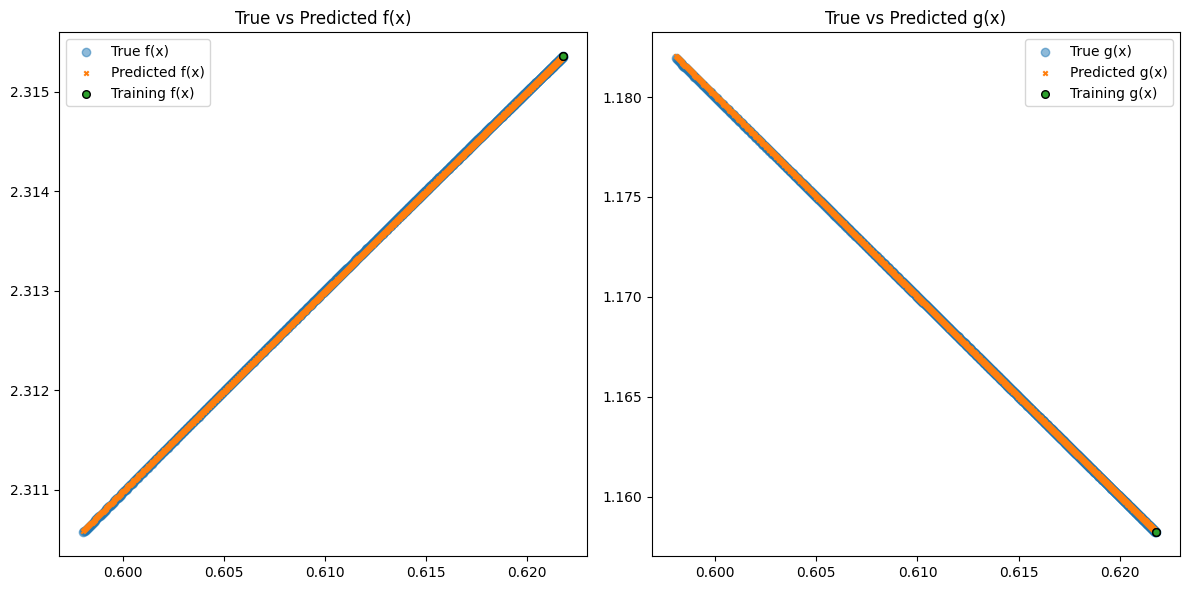

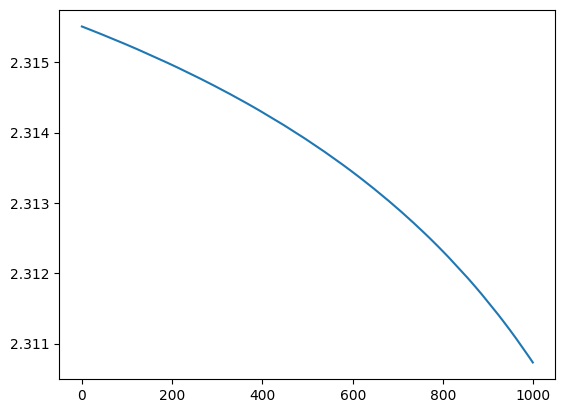

In [ ]:
factor = 1
k4 = (1e-6*1e4)*factor
k4_mean_torch = torch.tensor(k4, dtype=torch.float64)
# V_cell = k1 + k2 * torch.log(i_cell) + k3 * (1/lm) * i_cell
f_func = lambda x,y: k1_mean_torch*torch.ones_like(x) + k2_mean_torch*torch.log(x) + k3_mean_torch * (1/y) * x
g_func = lambda x: 1.78e-2*factor - k4_mean_torch*x

x_phys = i_cell.reshape(-1,1)
f_test = f_func(x_phys,g_func(x_phys)).detach().numpy()
g_test = g_func(x_phys).detach().numpy()

plt.plot(f_test, label='f_test')

#### EXAMPLE OF DUALOUTPUT CLASS

Epoch 0: Total Loss = 0.449184, MSE Loss = 0.002128, Physics Loss = 0.447056
Epoch 100: Total Loss = 0.043506, MSE Loss = 0.000001, Physics Loss = 0.043505
Epoch 200: Total Loss = 0.001308, MSE Loss = 0.000079, Physics Loss = 0.001229
Epoch 300: Total Loss = 0.000576, MSE Loss = 0.000000, Physics Loss = 0.000576
Epoch 400: Total Loss = 0.000281, MSE Loss = 0.000000, Physics Loss = 0.000281
Epoch 500: Total Loss = 0.000142, MSE Loss = 0.000000, Physics Loss = 0.000142
Epoch 600: Total Loss = 0.000078, MSE Loss = 0.000000, Physics Loss = 0.000078
Epoch 700: Total Loss = 0.000053, MSE Loss = 0.000000, Physics Loss = 0.000053
Epoch 800: Total Loss = 0.000041, MSE Loss = 0.000000, Physics Loss = 0.000041
Epoch 900: Total Loss = 0.000841, MSE Loss = 0.000599, Physics Loss = 0.000242
Training complete!


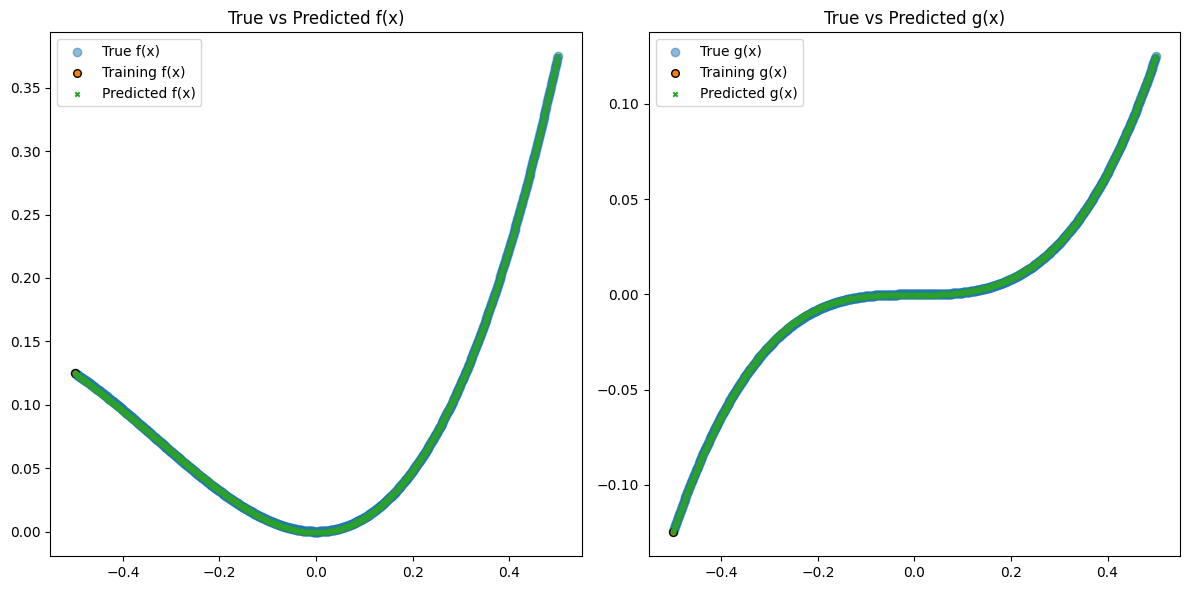

In [51]:
# Define the functions using lambda
f_func = lambda x: x ** 3 + x**2
g_func = lambda x: x**3
ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, x_phys: df_dx  - (dg_dx + 2*x_phys)
# f_values, g_values, df_dx, dg_dx, x_phys
ode_residual_g_func = lambda dg_dx, x_phys: dg_dx - 3*x_phys**2

x_train_mse, y1_train, y2_train = generate_data(f_func=f_func, g_func=g_func, n_samples=10)
# Select only the first n points
n = 1 
x_train_mse, y1_train, y2_train = x_train_mse[:n], y1_train[:n], y2_train[:n]
x_phys, _, _ = generate_data(f_func=f_func, g_func=g_func, n_samples=1000)
model = DualOutputNN(y01=y1_train[0], y02=y2_train[0])
train(model=model, x_mse=x_train_mse, x_phys=x_phys, y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=1000,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)
f_test = f_func(x_phys.detach().numpy())
g_test = g_func(x_phys.detach().numpy())
plot_results(model,x_phys, x_train_mse, y1_train, y2_train, 
                f_test=f_test,g_test=g_test, f_func=None, g_func=None)


Epoch 0: Total Loss = 0.564831, MSE Loss = 0.122212, Physics Loss = 0.442619
Epoch 100: Total Loss = 0.046722, MSE Loss = 0.000006, Physics Loss = 0.046716
Epoch 200: Total Loss = 0.003746, MSE Loss = 0.000000, Physics Loss = 0.003746
Epoch 300: Total Loss = 0.001305, MSE Loss = 0.000000, Physics Loss = 0.001305
Epoch 400: Total Loss = 0.000125, MSE Loss = 0.000000, Physics Loss = 0.000125
Epoch 500: Total Loss = 0.000058, MSE Loss = 0.000000, Physics Loss = 0.000058
Epoch 600: Total Loss = 0.000053, MSE Loss = 0.000000, Physics Loss = 0.000053
Epoch 700: Total Loss = 0.000345, MSE Loss = 0.000078, Physics Loss = 0.000267
Epoch 800: Total Loss = 0.000046, MSE Loss = 0.000000, Physics Loss = 0.000046
Epoch 900: Total Loss = 0.000043, MSE Loss = 0.000000, Physics Loss = 0.000043
Training complete!


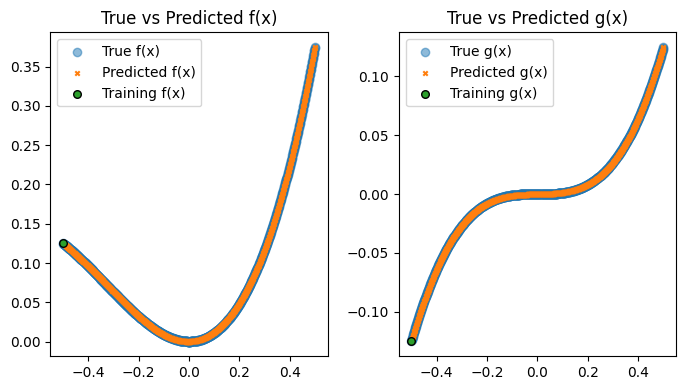

In [5]:
# Neural Network Model
class DualOutputNN(nn.Module):
    def __init__(self):
        super(DualOutputNN, self).__init__()
        self.hidden = nn.Sequential(
            nn.Linear(1, 32),
            nn.Sigmoid(),
            nn.Linear(32, 32),
            nn.Sigmoid()
        )
        self.output1 = nn.Linear(32, 1)  # First output
        self.output2 = nn.Linear(32, 1)  # Second output

    def forward(self, x):
        features = self.hidden(x)
        y1 = self.output1(features)  # f(x) prediction
        y2 = self.output2(features)  # g(x) prediction
        return y1, y2
    
    def physics_loss(self, x_phys, ode_residual_f_func, ode_residual_g_func):
        """
        Computes the physics-based loss for the given physical inputs and ODE residual functions.
        Args:
            x_phys (torch.Tensor): The physical input tensor.
            f_values (torch.Tensor): The target values for the first function.
            g_values (torch.Tensor): The target values for the second function.
            ode_residual_f_func (callable): A function that computes the ODE residual for the first function.
            ode_residual_g_func (callable): A function that computes the ODE residual for the second function.
        Returns:
            torch.Tensor: The computed physics-based loss.
        Example of ode_residual_f_func:
            ode_residual_f_func = lambda df_dx, dg_dx, x_phys: df_dx + dg_dx - x_phys
        Example of ode_residual_g_func:
            ode_residual_g_func = lambda dg_dx, x_phys: dg_dx - x_phys
        """
        x_phys.requires_grad = True
        y1, y2 = self.forward(x_phys)
        f_pred, g_pred = y1, y2

        df_dx = torch.autograd.grad(f_pred, x_phys, torch.ones_like(f_pred), create_graph=True)[0]
        dg_dx = torch.autograd.grad(g_pred, x_phys, torch.ones_like(g_pred), create_graph=True)[0]
        
        ode_residual_f = ode_residual_f_func(df_dx, dg_dx, x_phys)
        ode_residual_g = ode_residual_g_func(dg_dx, x_phys)
        
        return torch.mean(ode_residual_f**2) + torch.mean(ode_residual_g**2)
    
    def mse_loss(self, x_data, f_data, g_data):
        f_pred, g_pred = self.forward(x_data)
        # f_pred, g_pred = u_pred[:, 0:1], u_pred[:, 1:2]
        loss_f = nn.MSELoss()(f_pred, f_data)
        loss_g = nn.MSELoss()(g_pred, g_data)
        return loss_f + loss_g

# Training function
def train(model, x_mse, x_phys, y1_train, y2_train, ode_residual_f_func, ode_residual_g_func, epochs=1000, lr=0.01,
          lambda_mse = 1.0, lambda_phys = 1.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        # y1_pred, y2_pred = model(x_train)
        # loss1 = criterion(y1_pred, y1_train)
        # loss2 = criterion(y2_pred, y2_train)
        # loss = loss1 + loss2  # Combined loss
        loss_mse = model.mse_loss(x_mse, y1_train, y2_train)
        physics_loss = model.physics_loss(x_phys, ode_residual_f_func, ode_residual_g_func)
        loss = lambda_phys * physics_loss + lambda_mse * loss_mse
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Total Loss = {loss.item():.6f}, MSE Loss = {loss_mse.item():.6f}, Physics Loss = {physics_loss.item():.6f}")
    print("Training complete!")

# Function to plot results
def plot_results(model, x_test, x_train_mse, f_func, g_func,figsize=(7, 4)):
    model.eval()
    with torch.no_grad():
        y1_pred, y2_pred = model(x_test)
    
    x_test_np = x_test.detach().numpy()
    x_train_mse_np = x_train_mse.detach().numpy()
    y1_pred_np = y1_pred.detach().numpy()
    y2_pred_np = y2_pred.detach().numpy()
    
    plt.figure(figsize=figsize)

    # Subplot for f(x)
    plt.subplot(1, 2, 1)
    plt.scatter(x_test_np, f_func(x_test_np), label="True f(x)", alpha=0.5)
    plt.scatter(x_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
    plt.scatter(x_train_mse_np, f_func(x_train_mse_np), label="Training f(x)", marker='o', s=30, edgecolor='k')
    plt.legend()
    plt.title("True vs Predicted f(x)")

    # Subplot for g(x)
    plt.subplot(1, 2, 2)
    plt.scatter(x_test_np, g_func(x_test_np), label="True g(x)",  alpha=0.5)
    plt.scatter(x_test_np, y2_pred_np, label="Predicted g(x)",  marker='x', s=10)
    plt.scatter(x_train_mse_np, g_func(x_train_mse_np), label="Training g(x)", marker='o', s=30, edgecolor='k')
    plt.legend()
    plt.title("True vs Predicted g(x)")

    plt.tight_layout()
    plt.show()



# Define the functions using lambda
f_func = lambda x: x ** 3 + x**2
g_func = lambda x: x**3
ode_residual_f_func = lambda df_dx, dg_dx, x_phys: df_dx  - (dg_dx + 2*x_phys)
ode_residual_g_func = lambda dg_dx, x_phys: dg_dx - 3*x_phys**2

x_train_mse, y1_train, y2_train = generate_data(f_func=f_func, g_func=g_func, n_samples=10)
# Select only the first n points
n = 1 
x_train_mse, y1_train, y2_train = x_train_mse[:n], y1_train[:n], y2_train[:n]
x_phys, _, _ = generate_data(f_func=f_func, g_func=g_func, n_samples=1000)
model = DualOutputNN()
train(model=model, x_mse=x_train_mse, x_phys=x_phys, y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=1000,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)
plot_results(model,x_phys, x_train_mse, f_func, g_func)



## PARAMETER INFERENCE

In [11]:
# Neural Network Model
class DualOutputNN(nn.Module):
    def __init__(self, t0, y01, y02):
        super(DualOutputNN, self).__init__()
        self.hidden = nn.Sequential(
            nn.Linear(1, 32),
            nn.Sigmoid(),
            nn.Linear(32, 32),
            nn.Sigmoid()
        )
        self.output1 = nn.Linear(32, 1)  # First output
        self.output2 = nn.Linear(32, 1)  # Second output
        
        self.t0 = t0
        self.y01 = y01
        self.y02 = y02

        # Define k as a learnable parameter
        self.k = nn.Parameter(torch.tensor(0.1, dtype=torch.float32))

    def forward(self, x):
        features = self.hidden(x)
        y1 = torch.exp(self.output1(features))
        y2 = torch.exp(self.output2(features))
        return y1, y2
    
    def physics_loss(self, t_phys, x_phys, ode_residual_f_func, ode_residual_g_func, lambda_phys_f, lambda_phys_g):
        t_phys.requires_grad = True
        y1, y2 = self.forward(t_phys)
        f_pred, g_pred = y1, y2

        df_dx = torch.autograd.grad(f_pred, t_phys, torch.ones_like(f_pred), create_graph=True)[0]
        dg_dx = torch.autograd.grad(g_pred, t_phys, torch.ones_like(g_pred), create_graph=True)[0]
        
        ode_residual_f = ode_residual_f_func(f_pred, g_pred, df_dx, dg_dx, t_phys, x_phys)
        ode_residual_g = ode_residual_g_func(dg_dx, t_phys, self.k)
        
        return lambda_phys_f * torch.mean(ode_residual_f**2) + lambda_phys_g * torch.mean(ode_residual_g**2)
    
    def mse_loss(self, t_data, f_data, g_data, lambda_mse_f, lambda_mse_g):
        f_pred, g_pred = self.forward(t_data)
        loss_f = nn.MSELoss()(f_pred, f_data)
        loss_g = nn.MSELoss()(g_pred, g_data)
        return lambda_mse_f * loss_f + lambda_mse_g * loss_g

# Training function
def train(model, t_mse, t_phys, x_phys, y1_train, y2_train, ode_residual_f_func, ode_residual_g_func, epochs=1000, lr=0.01,
          lambda_mse=1.0, lambda_phys=1.0, lambda_phys_f=1.0, lambda_phys_g=1.0, lambda_mse_f=1.0, lambda_mse_g=1.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss_mse = model.mse_loss(t_mse, y1_train, y2_train, lambda_mse_f=lambda_mse_f, lambda_mse_g=lambda_mse_g)
        physics_loss = model.physics_loss(t_phys, x_phys, ode_residual_f_func, ode_residual_g_func, 
                                          lambda_phys_f=lambda_phys_f, lambda_phys_g=lambda_phys_g)
        loss = lambda_phys * physics_loss + lambda_mse * loss_mse
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Total Loss = {loss.item():.6f}, MSE Loss = {loss_mse.item():.6f}, Physics Loss = {physics_loss.item():.6f}, k = {model.k.item():.6f}")
    print("Training complete!")

# Function to plot results
def plot_results(model, t_test, t_train_mse, f_train, g_train, f_test, g_test, f_func=None, g_func=None):
    model.eval()
    with torch.no_grad():
        y1_pred, y2_pred = model(t_test)
    
    t_test_np = t_test.detach().numpy()
    t_train_mse_np = t_train_mse.detach().numpy()
    y1_pred_np = y1_pred.detach().numpy()
    y2_pred_np = y2_pred.detach().numpy()
    
    plt.figure(figsize=(12, 6))

    # Subplot for f(x)
    plt.subplot(1, 2, 1)
    if f_func:
        plt.scatter(t_test_np, f_func(t_test_np), label="True f(x)", alpha=0.5)
        plt.scatter(t_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, f_func(t_train_mse_np), label="Training f(x)", marker='o', s=30, edgecolor='k')
    else:
        plt.scatter(t_test_np, f_test, label="True f(x)", alpha=0.5)
        plt.scatter(t_test_np, y1_pred_np, label="Predicted f(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, f_train, label="Training f(x)", marker='o', s=30, edgecolor='k')
    plt.legend()
    plt.title("True vs Predicted f(x)")

    # Subplot for g(x)
    plt.subplot(1, 2, 2)
    if g_func:
        plt.scatter(t_test_np, g_func(t_test_np), label="True g(x)", alpha=0.5)
        plt.scatter(t_test_np, y2_pred_np, label="Predicted g(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, g_func(t_train_mse_np), label="Training g(x)", marker='o', s=30, edgecolor='k')
    else:
        plt.scatter(t_test_np, g_test, label="True g(x)", alpha=0.5)
        plt.scatter(t_test_np, y2_pred_np, label="Predicted g(x)", marker='x', s=10)
        plt.scatter(t_train_mse_np, g_train, label="Training g(x)", marker='o', s=30, edgecolor='k')
    
    plt.legend()
    plt.title("True vs Predicted g(x)")

    plt.tight_layout()
    plt.show()



------------------------------- QUADRATIC DECREASE ------------------------
Epoch 0: Total Loss = 3.019489, MSE Loss = 3.003534, Physics Loss = 0.015955, k = 0.090000
Epoch 100: Total Loss = 0.090040, MSE Loss = 0.078133, Physics Loss = 0.011907, k = 0.122853
Epoch 200: Total Loss = 0.067452, MSE Loss = 0.054334, Physics Loss = 0.013118, k = 0.255047
Epoch 300: Total Loss = 0.015799, MSE Loss = 0.007888, Physics Loss = 0.007911, k = 0.726793
Epoch 400: Total Loss = 0.004642, MSE Loss = 0.002211, Physics Loss = 0.002430, k = 0.854576
Epoch 500: Total Loss = 0.000788, MSE Loss = 0.000151, Physics Loss = 0.000637, k = 0.962945
Epoch 600: Total Loss = 0.000486, MSE Loss = 0.000039, Physics Loss = 0.000447, k = 0.981558
Epoch 700: Total Loss = 0.000360, MSE Loss = 0.000031, Physics Loss = 0.000329, k = 0.985577
Epoch 800: Total Loss = 0.000271, MSE Loss = 0.000013, Physics Loss = 0.000258, k = 0.989387
Epoch 900: Total Loss = 0.000463, MSE Loss = 0.000123, Physics Loss = 0.000340, k = 0.988

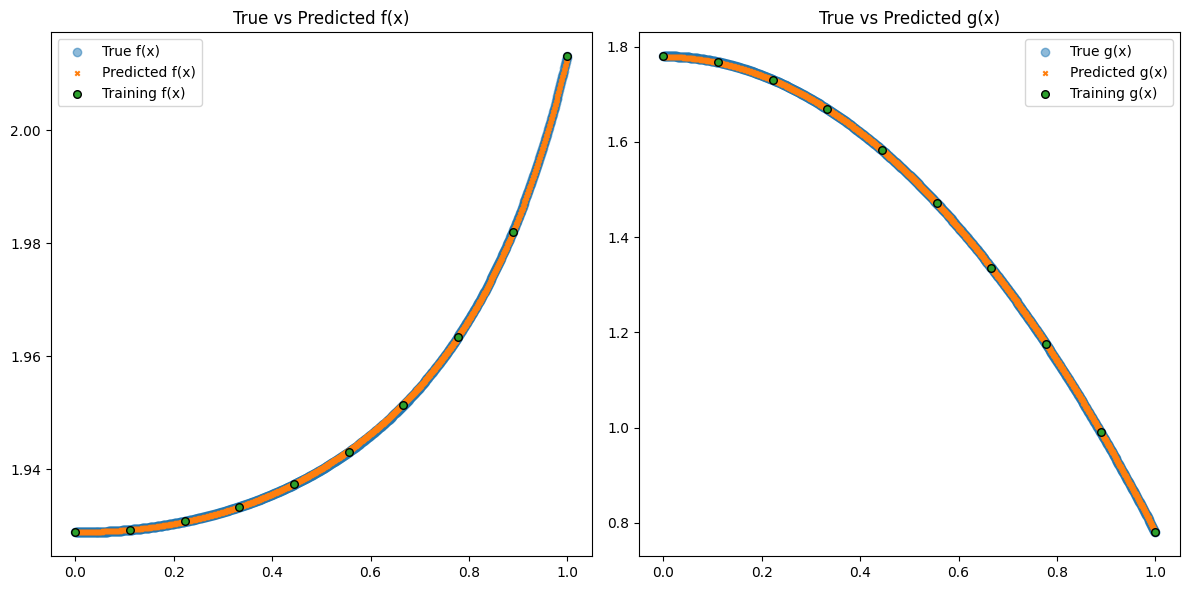

Inferred k: 0.9971808195114136


In [14]:
### VOLTAGE TRAINING
torch.manual_seed(0)

## Print at the beginning that this is the quadratic case
print('------------------------------- QUADRATIC DECREASE ------------------------')

ini = 0.5
fin = 1.5
factor = 1e2
Area_cell = 680
k4 = (1e-6*1e4)*factor
k4_mean_torch = torch.tensor(k4, dtype=torch.float64)
t_phys = torch.tensor(df['Time'].values, dtype=torch.float32).reshape(-1, 1)
P_area = torch.tensor(df['P'].values/Area_cell, dtype=torch.float32).reshape(-1, 1)
# k = k4_mean_torch


############## OPTION 1: USING I_cell values to compute V_cell  ################
# V_cell = k1 + k2 * torch.log(i_cell) + k3 * (1/lm) * i_cell
# f_func = lambda x,y: k1_mean_torch*torch.ones_like(x) + k2_mean_torch*torch.log(x) + k3_mean_torch * (factor/y) * x
# x_phys = i_cell.reshape(-1,1)
# # Compute the numerical derivative of x_phys with respect to t_phys
# dx_dt = torch.gradient(x_phys.squeeze(), spacing=(t_phys.squeeze(),))[0].reshape(-1, 1)
####### TODO: FALTA EL TERMINO DE d_icell/dx
# ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, t_phys, x_phys: df_dx  - (k2_mean_torch/x_phys*dx_dt+ k3_mean_torch * factor * ((1/g_values)*dx_dt+x_phys*(-dg_dx/g_values**2)))

#############  OPTION 2: USING directly V_cell values  ################
# V_cell = k1 + k2*torch.log(P/(a_cell*V_cell)) + k3*(1/lm)*P/(a_cell*V_cell)
# f_func = lambda x,y: k1_mean_torch*torch.ones_like(x) + k2_mean_torch*torch.log(P_area/x) + k3_mean_torch * (factor/y) * P_area/x
x_phys = f_values.reshape(-1, 1)
# Compute the numerical derivative of x_phys with respect to t_phys
# dx_dt = torch.gradient(x_phys.squeeze(), spacing=(t_phys.squeeze(),))[0].reshape(-1, 1)
# ode_residual_f_func = lambda f_values, g_values, df_dx, dg_dx, t_phys, x_phys: df_dx  - (-k2_mean_torch/x_phys*dx_dt+ k3_mean_torch * factor * ((1/g_values)*dx_dt+x_phys*(-dg_dx/g_values**2)))
ode_residual_f_func = lambda f_predd, g_predd, df_dx, dg_dx, t_phys, x_phys: df_dx  - (-k2_mean_torch * df_dx/f_predd + k3_mean_torch * factor * P_area*(-(dg_dx/(f_predd*g_predd**2))-((df_dx)/(g_predd*f_predd**2))))


# g_func = lambda t, k: 1.78e-2*factor - k*t**2
ode_residual_g_func = lambda dg_dx, t_phys, k: dg_dx - (-2*k*t_phys)


t_train_mse = torch.tensor(df['Time'].values, dtype=torch.float32).reshape(-1, 1)
# x_train_mse = i_cell.reshape(-1,1)
x_train_mse = f_values.reshape(-1,1)
# y2_train = g_func(t_train_mse, k4_mean_torch)
# y1_train = f_func(x_train_mse,y2_train)
y2_train = factor*torch.tensor(df['memThickness'].values, dtype=torch.float32).reshape(-1, 1)
y1_train = torch.tensor(df['V'].values, dtype=torch.float32).reshape(-1, 1)
 

# Select 10 equally spaced points in the first half of the data
n = 10
half_index = len(t_train_mse)
indices = torch.linspace(0, half_index - 1, n).long()
t_train_mse, x_train_mse, y1_train, y2_train = t_train_mse[indices], x_train_mse[indices], y1_train[indices], y2_train[indices]



model = DualOutputNN(t0=t_train_mse[0],y01=y1_train[0], y02=y2_train[0])
train(model=model, t_mse=t_train_mse, t_phys=t_phys,x_phys =x_phys,  y1_train= y1_train,
        y2_train=y2_train,lambda_phys=1.0, lambda_mse=1.0, epochs=2000,
        lambda_phys_f=1.0, lambda_phys_g=1.0,lambda_mse_f=1.0, lambda_mse_g=1,
        ode_residual_f_func=ode_residual_f_func, ode_residual_g_func=ode_residual_g_func)

# g_test = g_func(t_phys, model.k.item()).detach().numpy()
# f_test = f_func(x_phys,g_func(t_phys,model.k.item())).detach().numpy()
g_test = factor*df['memThickness'].values
f_test = df['V'].values

plot_results(model,t_phys, t_train_mse, y1_train, y2_train, 
                f_test=f_test,g_test=g_test, f_func=None, g_func=None)

#Print the inferred k 
print('Inferred k:', model.k.item())
